In [738]:
import ast
import os
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA, FastICA
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    average_precision_score, r2_score, log_loss,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from scipy.stats import rankdata



## Utility helpers

In [739]:
def load_tensor(path):
    assert os.path.exists(path), path
    return torch.load(path, map_location="cpu")

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def calculate_auc(true_val, pred_val):
    """Compute AUC, flip direction if < 0.5."""
    auc = roc_auc_score(true_val, pred_val)
    if auc < 0.5:
        auc = 1 - auc
    return auc




## Config and path helpers

In [740]:
def read_config_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        first_line = f.readline().strip()
    return ast.literal_eval(first_line)


def get_data_dir_name_from_log(experiment_path):
    log_path = os.path.join(experiment_path, "log.txt")
    assert os.path.exists(log_path), log_path
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("data_dir:"):
                return os.path.basename(os.path.normpath(line.split("data_dir:", 1)[1].strip()))
            elif line.startswith("Loading existing synthetic dataset from"):
                
                return os.path.basename(os.path.normpath(line.split("Loading existing synthetic dataset from", 1)[1].strip()))
    raise ValueError(f"Could not find data_dir in {log_path}")


def infer_data_path(experiment_path):
    """Resolve absolute path to the saved dataset directory."""
    data_dir_name = get_data_dir_name_from_log(experiment_path)
    candidate = os.path.join("datasets", "multilabel_synthetic", data_dir_name)
    if os.path.exists(candidate):
        return candidate
    raise FileNotFoundError(f"Dataset not found at {candidate}")


def get_multilabel_config(experiment_path):
    """Return (num_concepts, num_residuals, num_hid_tasks, num_obs_tasks, hid_dim, obs_dim)."""
    cfg = read_config_from_log(experiment_path)
    d = cfg["data"]
    return (
        d["num_concepts"],
        d["num_residuals"],
        d.get("num_hid_tasks", 3),
        d.get("num_obs_tasks", 1),
        d["hid_dim"],
        d["obs_dim"],
    )


def print_data_info(experiment_path):
    data_path = infer_data_path(experiment_path)
    info = os.path.join(data_path, "info.txt")
    if os.path.exists(info):
        with open(info, "r") as f:
            print(f.read())


## Data loading

In [741]:
def load_split(experiment_path, data_path, split: str,
               num_concepts: int, num_residuals: int):
    """
    Load one split worth of model outputs + dataset tensors.

    Model outputs (from experiment_path/<split>/):
        c_res_mu.pt                        — Gaussian mean of [concept, residual] logits
        concepts_residuals_pred_probs_mean — mean sigmoid probs over MC samples
        concepts_residuals_pred_probs_std  — std of sigmoid probs over MC samples
        concepts_residuals_sample_mean     — mean of hard Bernoulli samples

    Dataset tensors (from data_path/<split>/):
        x, concepts, residuals, y (multilabel),
        eta_concepts, eta_residuals,
        concept_signal, residual_signal,
        s_hid, s_obs,
        w_hid, w_obs, Sigma,
        hid_task_idx, obs_task_idx
    """
    model_split = os.path.join(experiment_path, split)
    data_split = os.path.join(data_path, split)

    if not os.path.exists(model_split):
        raise FileNotFoundError(
            f"Missing {model_split}. Run training with save_concept_and_residual_channel=True."
        )
    assert os.path.exists(data_split), data_split

    c_res_mu = load_tensor(os.path.join(model_split, "c_res_mu.pt"))
    cr_probs = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_mean.pt"))
    cr_probs_std = load_tensor(os.path.join(model_split, "concepts_residuals_pred_probs_std.pt"))
    cr_sample = load_tensor(os.path.join(model_split, "concepts_residuals_sample_mean.pt"))
    


    out = {
        # ── model outputs ──────────────────────────────────────────────
        "c_mu": c_res_mu[:, :num_concepts],
        "res_mu": c_res_mu[:, num_concepts:],
        "concept_probs": cr_probs[:, :num_concepts],
        "residual_probs": cr_probs[:, num_concepts:],
        "concept_probs_std": cr_probs_std[:, :num_concepts],
        "residual_probs_std": cr_probs_std[:, num_concepts:],
        "concept_sample_mean": cr_sample[:, :num_concepts],
        "residual_sample_mean": cr_sample[:, num_concepts:],
        # ── dataset tensors ────────────────────────────────────────────
        "x": load_tensor(os.path.join(data_split, "x.pt")),
        "concepts": load_tensor(os.path.join(data_split, "concepts.pt")),
        "hidden_residuals": load_tensor(os.path.join(data_split, "residuals.pt")),
        "y": load_tensor(os.path.join(data_split, "y.pt")),  # (n, K+J)
        "eta_concepts": load_tensor(os.path.join(data_split, "eta_concepts.pt")),
        "eta_residuals": load_tensor(os.path.join(data_split, "eta_residuals.pt")),
        "concept_signal": load_tensor(os.path.join(data_split, "concept_signal.pt")),
        "hidden_residual_signal": load_tensor(os.path.join(data_split, "residual_signal.pt")),
        "s_hid": load_tensor(os.path.join(data_split, "s_hid.pt")),  # (n, K)
        "s_obs": load_tensor(os.path.join(data_split, "s_obs.pt")),  # (n, J)
        "w_hid": load_tensor(os.path.join(data_split, "w_hid.pt")),
        "w_obs": load_tensor(os.path.join(data_split, "w_obs.pt")),
        "hid_task_idx": load_tensor(os.path.join(data_split, "hid_task_idx.pt")),
        "obs_task_idx": load_tensor(os.path.join(data_split, "obs_task_idx.pt")),
        "avg_model_covariance_matrix": load_tensor(os.path.join(model_split, "avg_covariance_matrix.pt")) if os.path.exists(os.path.join(model_split, "avg_covariance_matrix.pt")) else None,
        "data_sigma_matrix": load_tensor(os.path.join(data_split, "Sigma.pt")) if os.path.exists(os.path.join(data_split, "Sigma.pt")) else None,
    }
    

    # Sanity: row counts must agree
    n_model = out["res_mu"].shape[0]
    n_data = out["hidden_residuals"].shape[0]
    assert n_model == n_data, (
        f"{split}: model has {n_model} rows but data has {n_data}. "
        "Residual dump likely used a shuffled/drop_last loader."
    )
    return out


## Specify experiment

In [742]:

# updated alpha=1, beta=1, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-02_13-13-54_337de"
# )





# updated (save avg model covariance) alpha=1, beta=1, sigma_x = 0.5, standardize=True
# EXPERIMENT_PATH = os.path.join("experiments", "scbm_residual", "multilabel_synthetic",
#                                "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-07-02_13-13-54_c7cfa"
# )

# # alpha=1, beta=0, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-46_2214e"
# )


# alpha=1, beta=0, sigma_x = 0.5, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-06-30_18-02-32_80deb"
# )



# important
# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-06-30_18-02-43_18266"
# )



# alpha=1, beta=1, sigma_x = 0.5, standardize=True, block_diagonal_cov = True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_block_diagonal_cov_True_2026-07-01_17-38-56_0b96b"   
# )

# alpha=1, beta=1, sigma_x = 0.01, standardize=True, block_diagonal_cov = True
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_block_diagonal_cov_True_2026-07-01_17-38-56_d2b0a"
# )


# alpha=1, beta=1, sigma_x = 0.5, standardize=True, cr_rho=0.5
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_num_res_20_2026-07-05_17-40-22_25c96"
# )


# alpha=1, beta=1, sigma_x = 0.5, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.5_standardize_True_paired_cov_num_res_20_2026-07-05_19-54-17_ab403"
# )

# alpha=1, beta=1, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.75_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-05_19-54-17_3f73e"
# )



# alpha=1, beta=1, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired, block_diagonal
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_1.0_rho_cr_0.75_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_17-14-22_d6a44"
# )


# alpha=1, beta=0.2, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired, block_diagonal
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.2_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_19-45-37_b2005"
# )

# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired, block_diagonal
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_block_diagonal_cov_True_2026-07-23_19-45-37_d98b6"
# )

# alpha=1, beta=0.2, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.2_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-23_23-41-08_c0ce9"
# )

# alpha=1, beta=0.5, sigma_x = 0.01, standardize=True, cr_rho=0.5, paired
# EXPERIMENT_PATH = os.path.join(
#     "experiments", "scbm_residual", "multilabel_synthetic",
#     "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.5_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_paired_cov_num_res_20_2026-07-23_23-41-28_02f4c"
# )




# New experiments

In [743]:
experiment_root = os.path.join("experiments", "scbm_residual", "multilabel_synthetic")

# alpha=1, beta=1, sigma_x = 0.01, standardize=True
EXPERIMENT_PATH = os.path.join(
    experiment_root,
    "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_500c9"
)







In [744]:
assert os.path.exists(EXPERIMENT_PATH), EXPERIMENT_PATH

# Resolve dataset path and config
DATA_PATH = infer_data_path(EXPERIMENT_PATH)

# change afterwards
print(f"DATA_PATH: {DATA_PATH}")

(num_concepts, num_residuals,
 num_hid_tasks, num_obs_tasks,
 hid_dim, obs_dim) = get_multilabel_config(EXPERIMENT_PATH)
num_tasks = num_hid_tasks + num_obs_tasks

print(f"num_concepts : {num_concepts}")
print(f"num_residuals: {num_residuals}")
print(f"num_hid_tasks: {num_hid_tasks}  (K)")
print(f"num_obs_tasks: {num_obs_tasks}  (J)")
print(f"num_tasks    : {num_tasks}  (K+J)")
print(f"hid_dim      : {hid_dim}")
print(f"obs_dim      : {obs_dim}")
print()
print_data_info(EXPERIMENT_PATH)
print(f"Block diagonal covariance: {read_config_from_log(EXPERIMENT_PATH)['model'].get('block_diagonal_cov', False)}")


DATA_PATH: datasets/multilabel_synthetic/cluster_hid_tasks_5_obs_tasks_2_alpha_1.0_beta_0.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.01_hid_dim_20_obs_dim_10_w_ratio_0.4_standardize_True_seed_0
num_concepts : 10
num_residuals: 20
num_hid_tasks: 5  (K)
num_obs_tasks: 2  (J)
num_tasks    : 7  (K+J)
hid_dim      : 20
obs_dim      : 10

[multilabel synthetic dataset]
num_hid_tasks : 5
num_obs_tasks : 2
num_tasks/num_classes : 7
alpha : 1.0
beta : 0.0
hid_task_idx : [5, 14, 7, 2, 17]
obs_task_idx : [4, 7]
rho_cr : 0.0
rho_cc : 0.0
rho_rr : 0.0
task_sparsity_hid : 0.25
task_sparsity_obs : 0.3
sigma_x : 0.01
hid_dim : 20
obs_dim : 10
seed : 0
train / val / test : 30000 / 10000 / 10000
min_weight_ratio : 0.4
data created for model at: /cluster/home/smarcou/work/experiments_scbm/scbm_residual/multilabel_synthetic/K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_500c9
standardize : Tr

## Load data splits

In [745]:
train_data = load_split(EXPERIMENT_PATH, DATA_PATH, "train",
                        num_concepts=num_concepts, num_residuals=num_residuals)
val_data = load_split(EXPERIMENT_PATH, DATA_PATH, "val",
                        num_concepts=num_concepts, num_residuals=num_residuals)
test_data = load_split(EXPERIMENT_PATH, DATA_PATH, "test",
                        num_concepts=num_concepts, num_residuals=num_residuals)
splits = {"train": train_data, "val": val_data, "test": test_data}

for split_name, data in splits.items():
    print(f"{split_name}:")
    for key in ["x", "res_mu", "hidden_residuals", "y", "s_hid", "s_obs"]:
        print(f"  {key:28s} {tuple(data[key].shape)}")

w_hid = train_data["w_hid"]
w_obs = train_data["w_obs"]
hid_task_idx = train_data["hid_task_idx"]  # (K,) — which hidden concepts are task bits
obs_task_idx = train_data["obs_task_idx"]  # (J,)


train:
  x                            (30000, 100)
  res_mu                       (30000, 20)
  hidden_residuals             (30000, 20)
  y                            (30000, 7)
  s_hid                        (30000, 5)
  s_obs                        (30000, 2)
val:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)
test:
  x                            (10000, 100)
  res_mu                       (10000, 20)
  hidden_residuals             (10000, 20)
  y                            (10000, 7)
  s_hid                        (10000, 5)
  s_obs                        (10000, 2)


## Task weights and task index mapping

In [746]:
# Hidden task weights — sorted by abs magnitude
df_w_hid = pd.DataFrame({
    "hidden_concept_idx": np.arange(w_hid.shape[0]),
    "weight": to_numpy(w_hid),
    "abs_weight": to_numpy(w_hid.abs()),
    "is_task_bit": [i in hid_task_idx.tolist() for i in range(w_hid.shape[0])],
})
df_w_hid = df_w_hid[df_w_hid["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

# Annotate which subtask index each hidden concept maps to
task_map_hid = {int(idx): k for k, idx in enumerate(hid_task_idx.tolist())}
print(f"task_map_hid: {task_map_hid}")
df_w_hid["hid_task_k"] = df_w_hid["hidden_concept_idx"].map(task_map_hid)

print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

# Observed task weights
df_w_obs = pd.DataFrame({
    "observed_concept_idx": np.arange(w_obs.shape[0]),
    "weight": to_numpy(w_obs),
    "abs_weight": to_numpy(w_obs.abs()),
    "is_task_bit": [i in obs_task_idx.tolist() for i in range(w_obs.shape[0])],
})
df_w_obs = df_w_obs[df_w_obs["abs_weight"] > 1e-8].sort_values("abs_weight", ascending=False)

task_map_obs = {int(idx): j for j, idx in enumerate(obs_task_idx.tolist())}
print(f"task_map_obs: {task_map_obs}")
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(task_map_obs)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)


task_map_hid: {5: 0, 14: 1, 7: 2, 2: 3, 17: 4}
Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4


task_map_obs: {4: 0, 7: 1}

Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


## Plot dataset balance

In [747]:
for split_name, data in splits.items():
    y = data["y"]
    label_ratio = y.mean(dim=0).detach().cpu().numpy()
    col = ["label ratio"] + [f"task {k}" for k in range(num_tasks)]
    df_label_ratio = pd.DataFrame({
        "task_idx": np.arange(num_tasks),
        "label_ratio": label_ratio,
    })
    print(f"{split_name}")
    display(df_label_ratio)
    

train


,task_idx,label_ratio
0,0,0.500367
1,1,0.498600
2,2,0.499367
3,3,0.501400
4,4,0.498233
5,5,0.501467
6,6,0.500500


val


,task_idx,label_ratio
0,0,0.4990
1,1,0.4995
2,2,0.4974
3,3,0.5007
4,4,0.5023
5,5,0.4964
6,6,0.4967


test


,task_idx,label_ratio
0,0,0.4999
1,1,0.5047
2,2,0.5045
3,3,0.4951
4,4,0.5030
5,5,0.4992
6,6,0.5018


## Data covariance

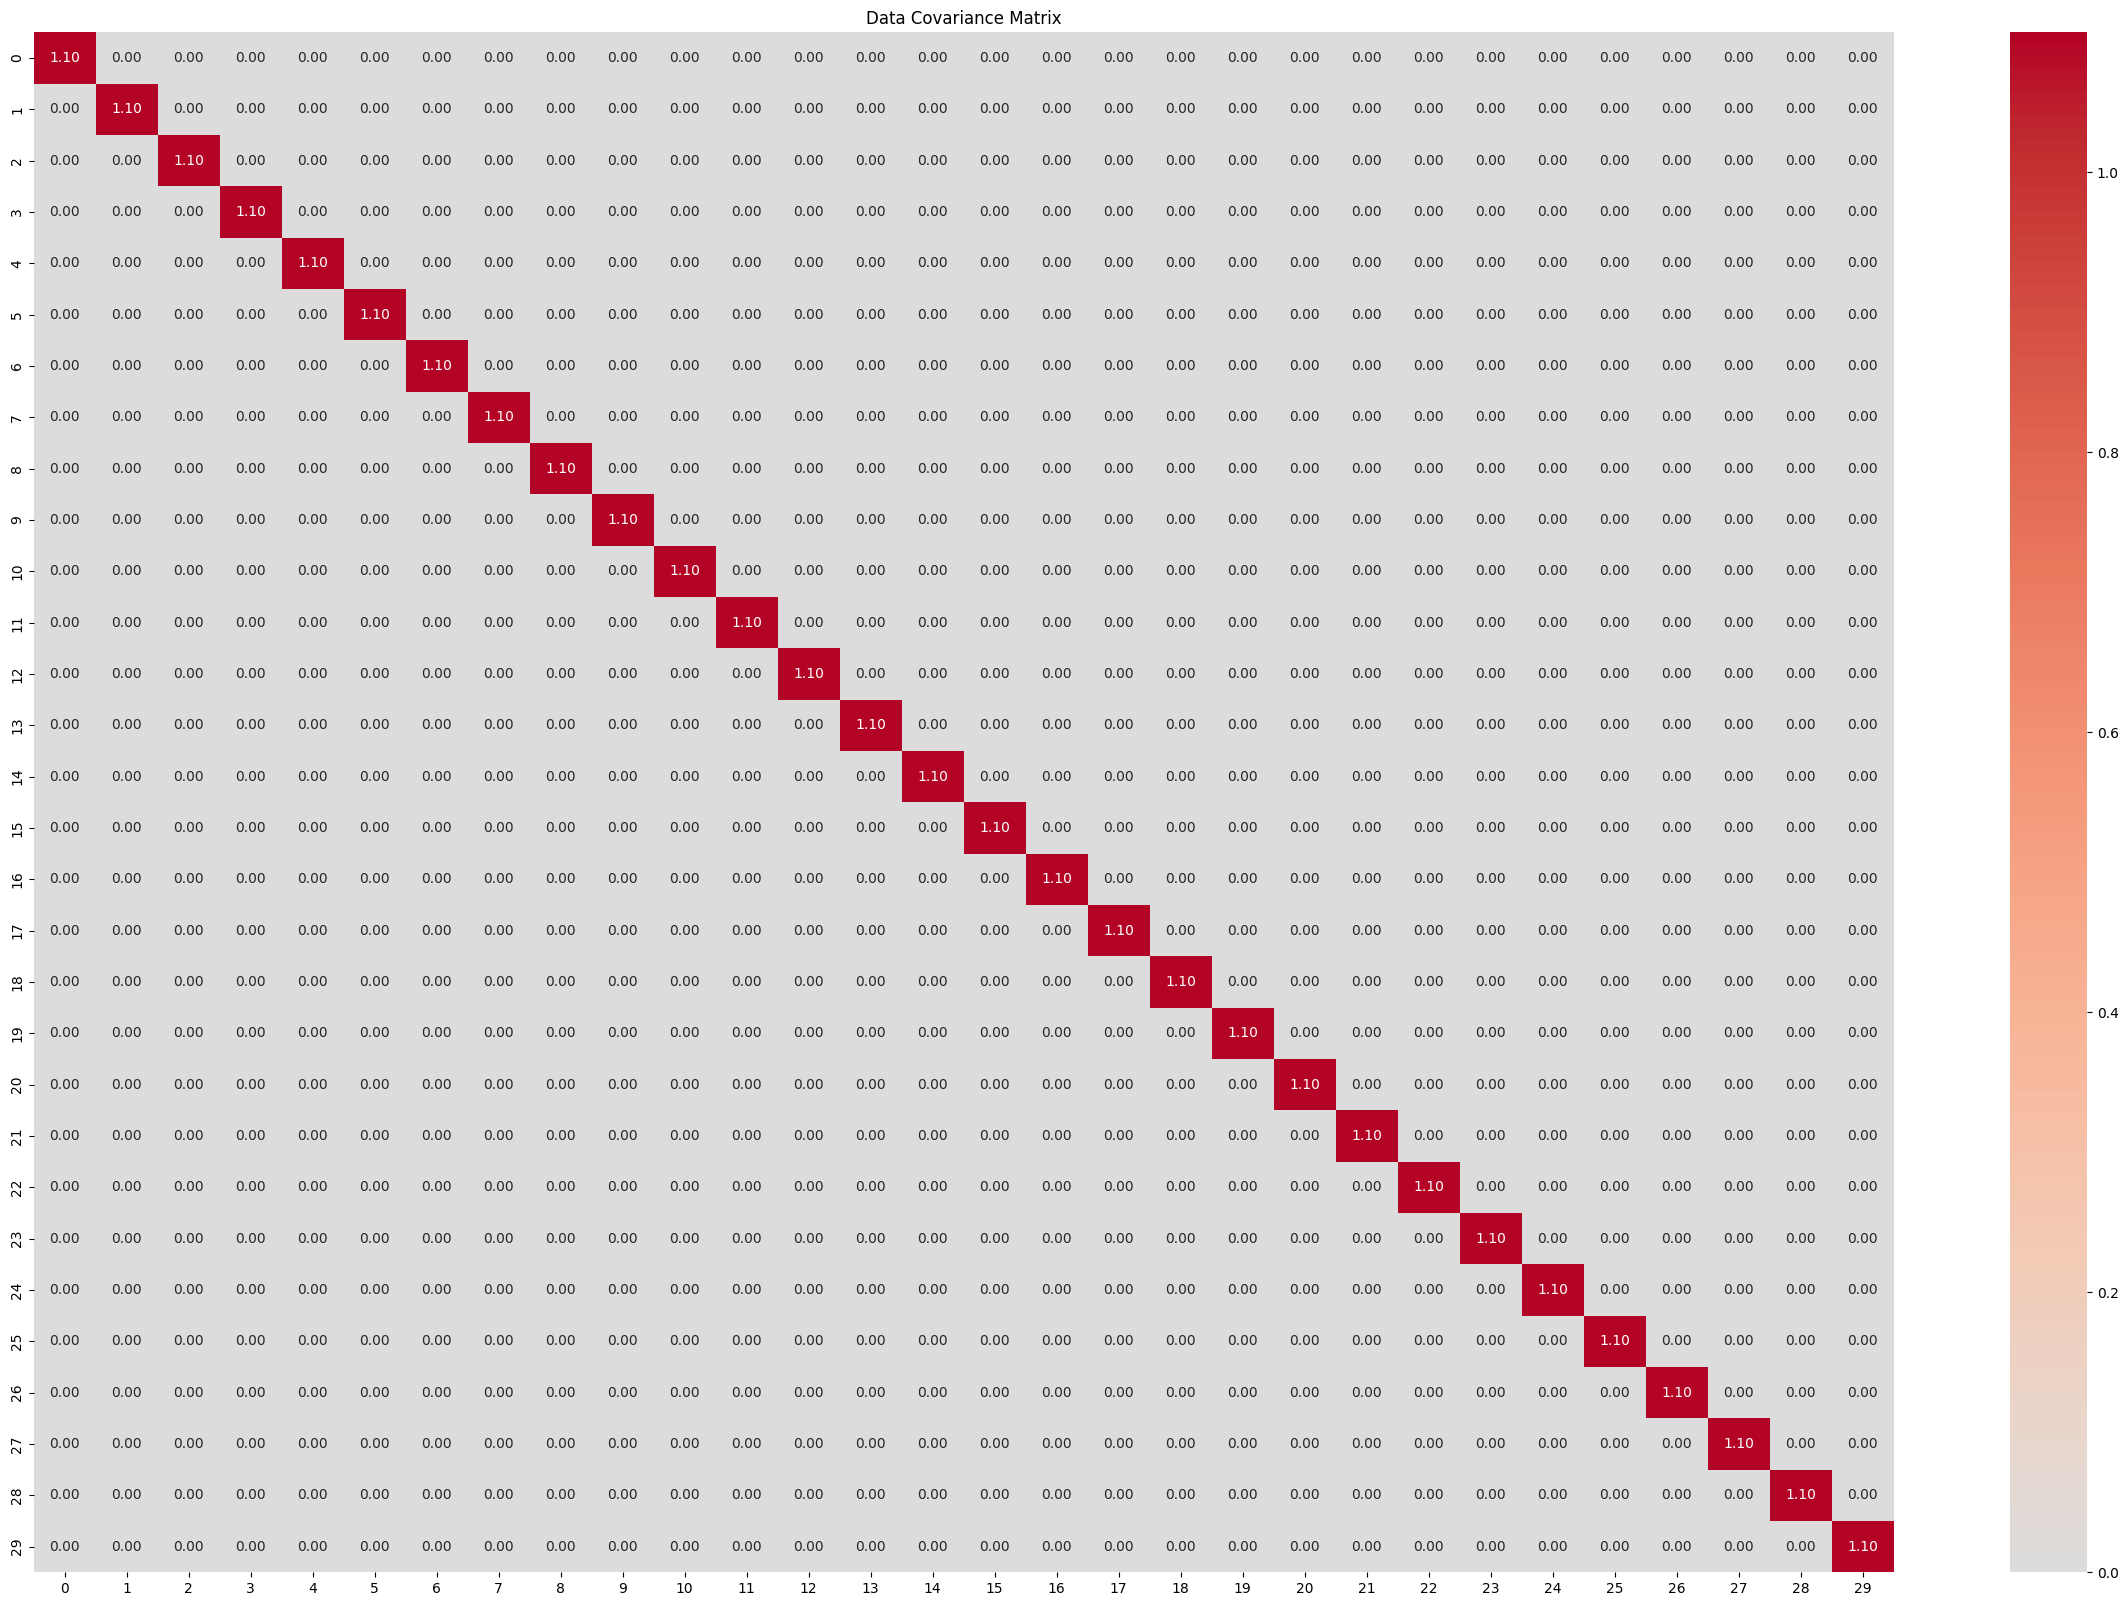

In [748]:
# All splits have same covariance matrix, so just plot one of them
train_data = splits["train"]
data_sigma_matrix = train_data["data_sigma_matrix"]
if data_sigma_matrix is not None:
    plt.figure(figsize=(30, 20))
    sns.heatmap(data_sigma_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(f"Data Covariance Matrix")
    plt.show()
        
        


## Model covariance

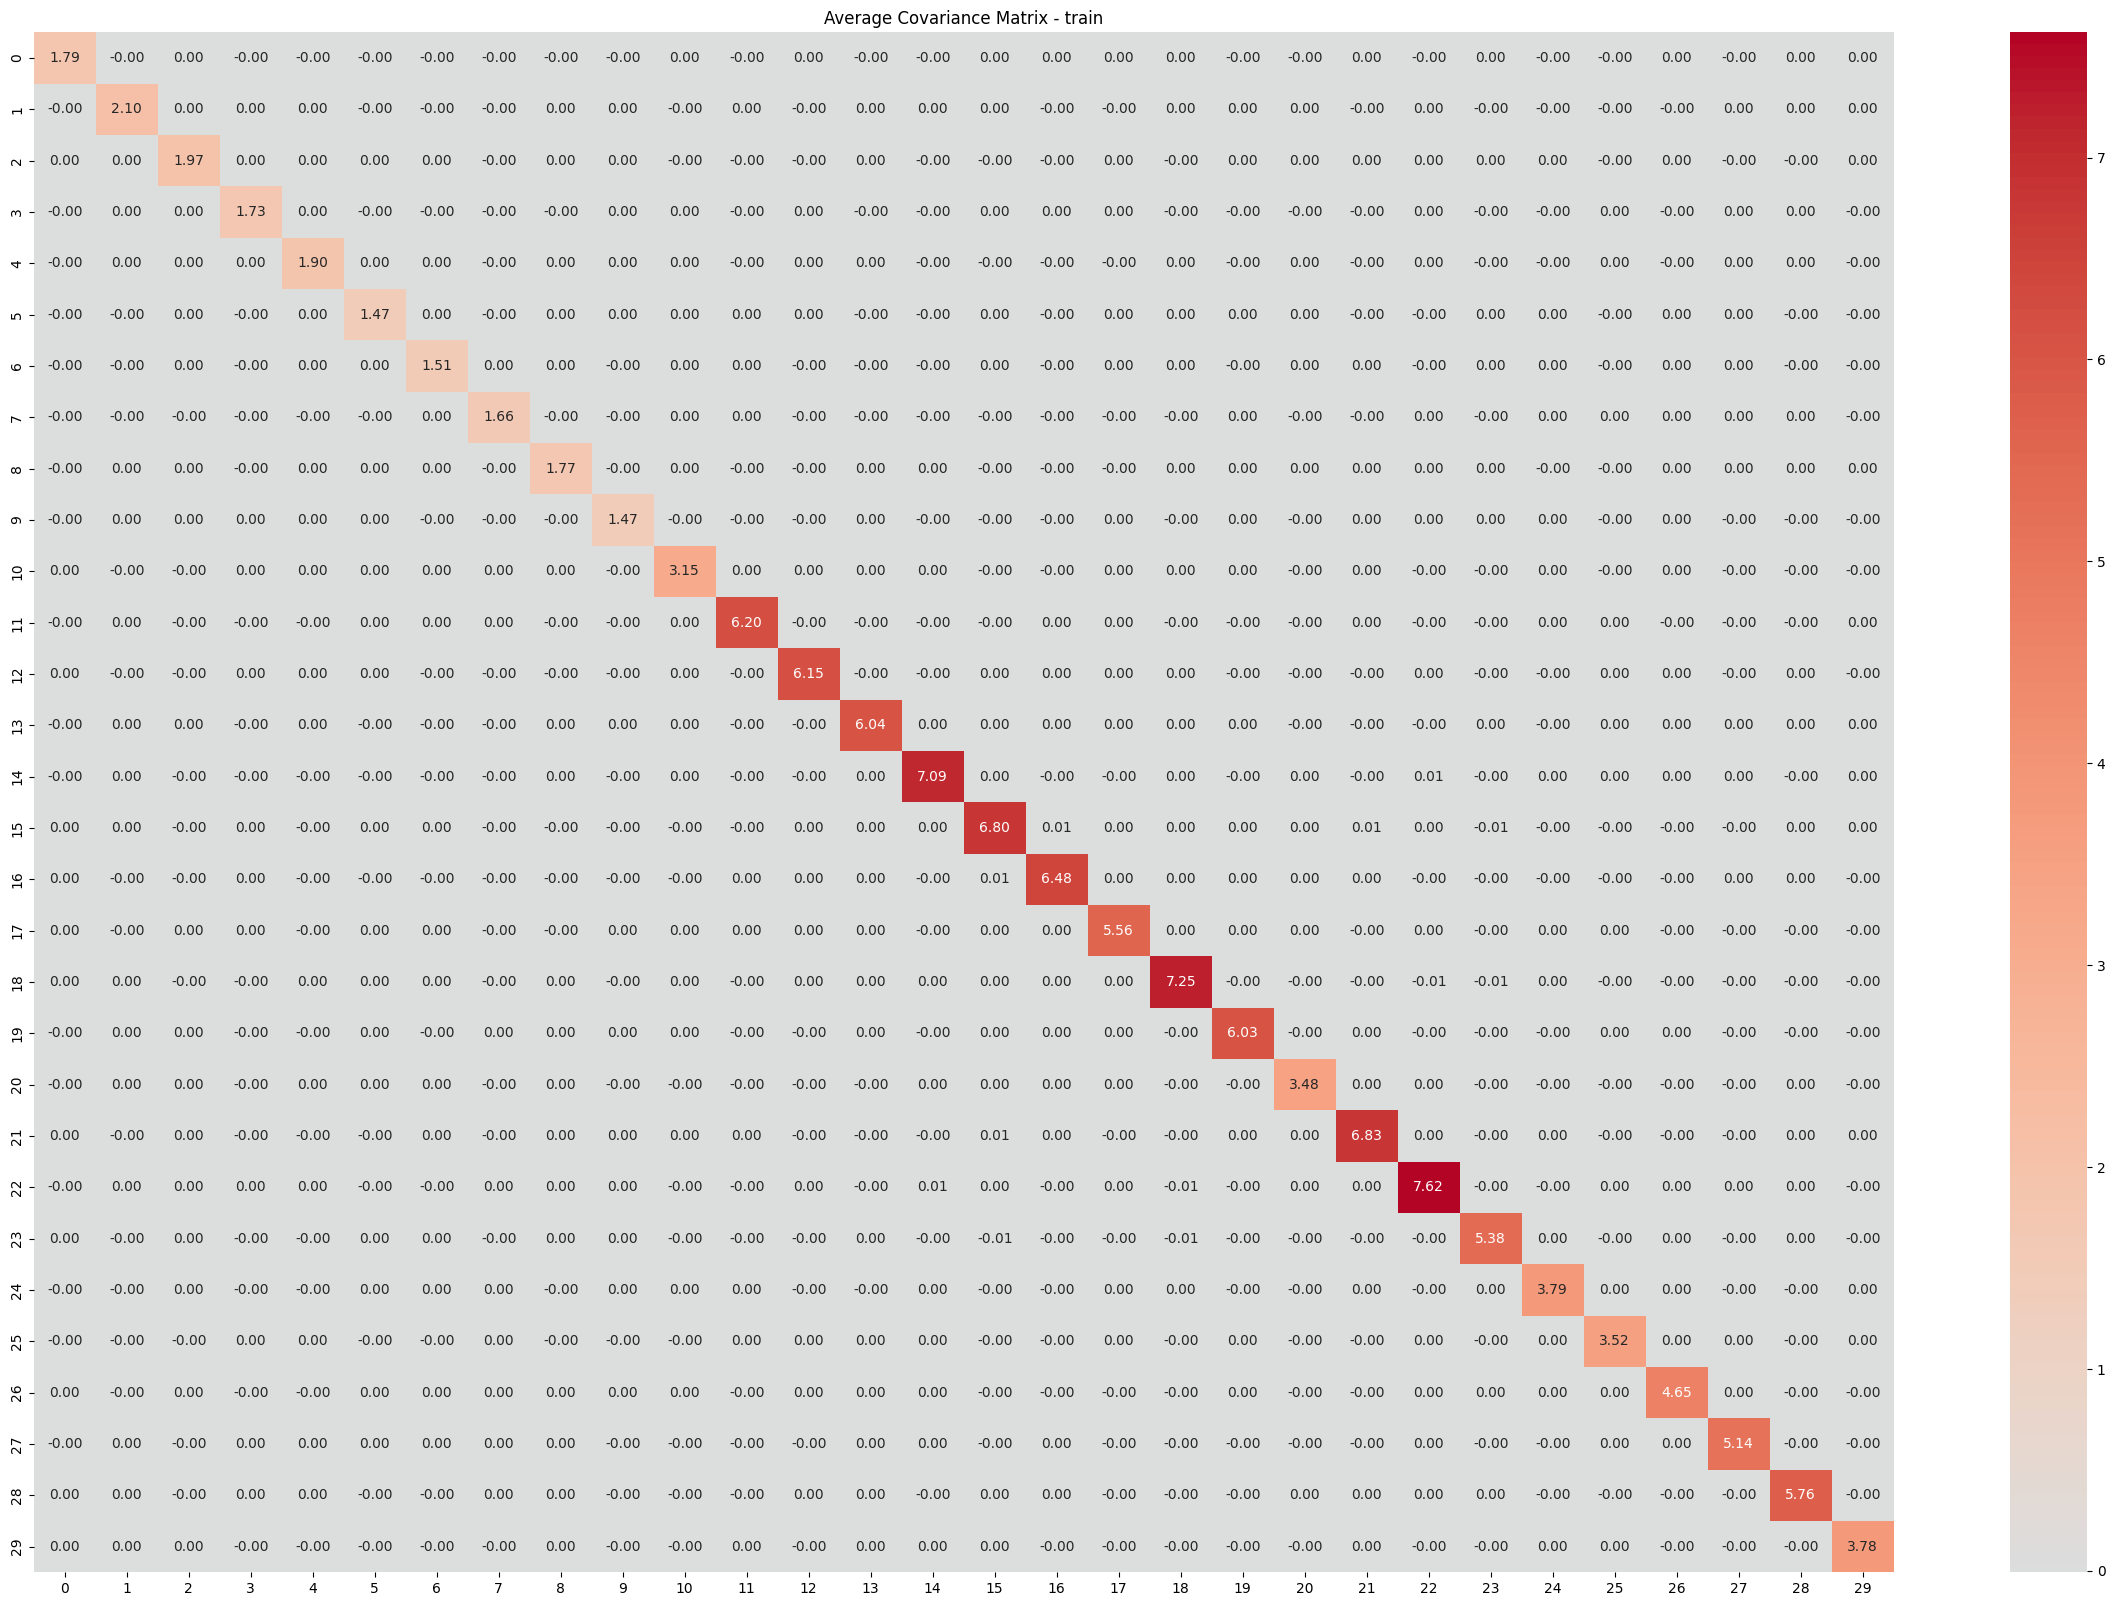

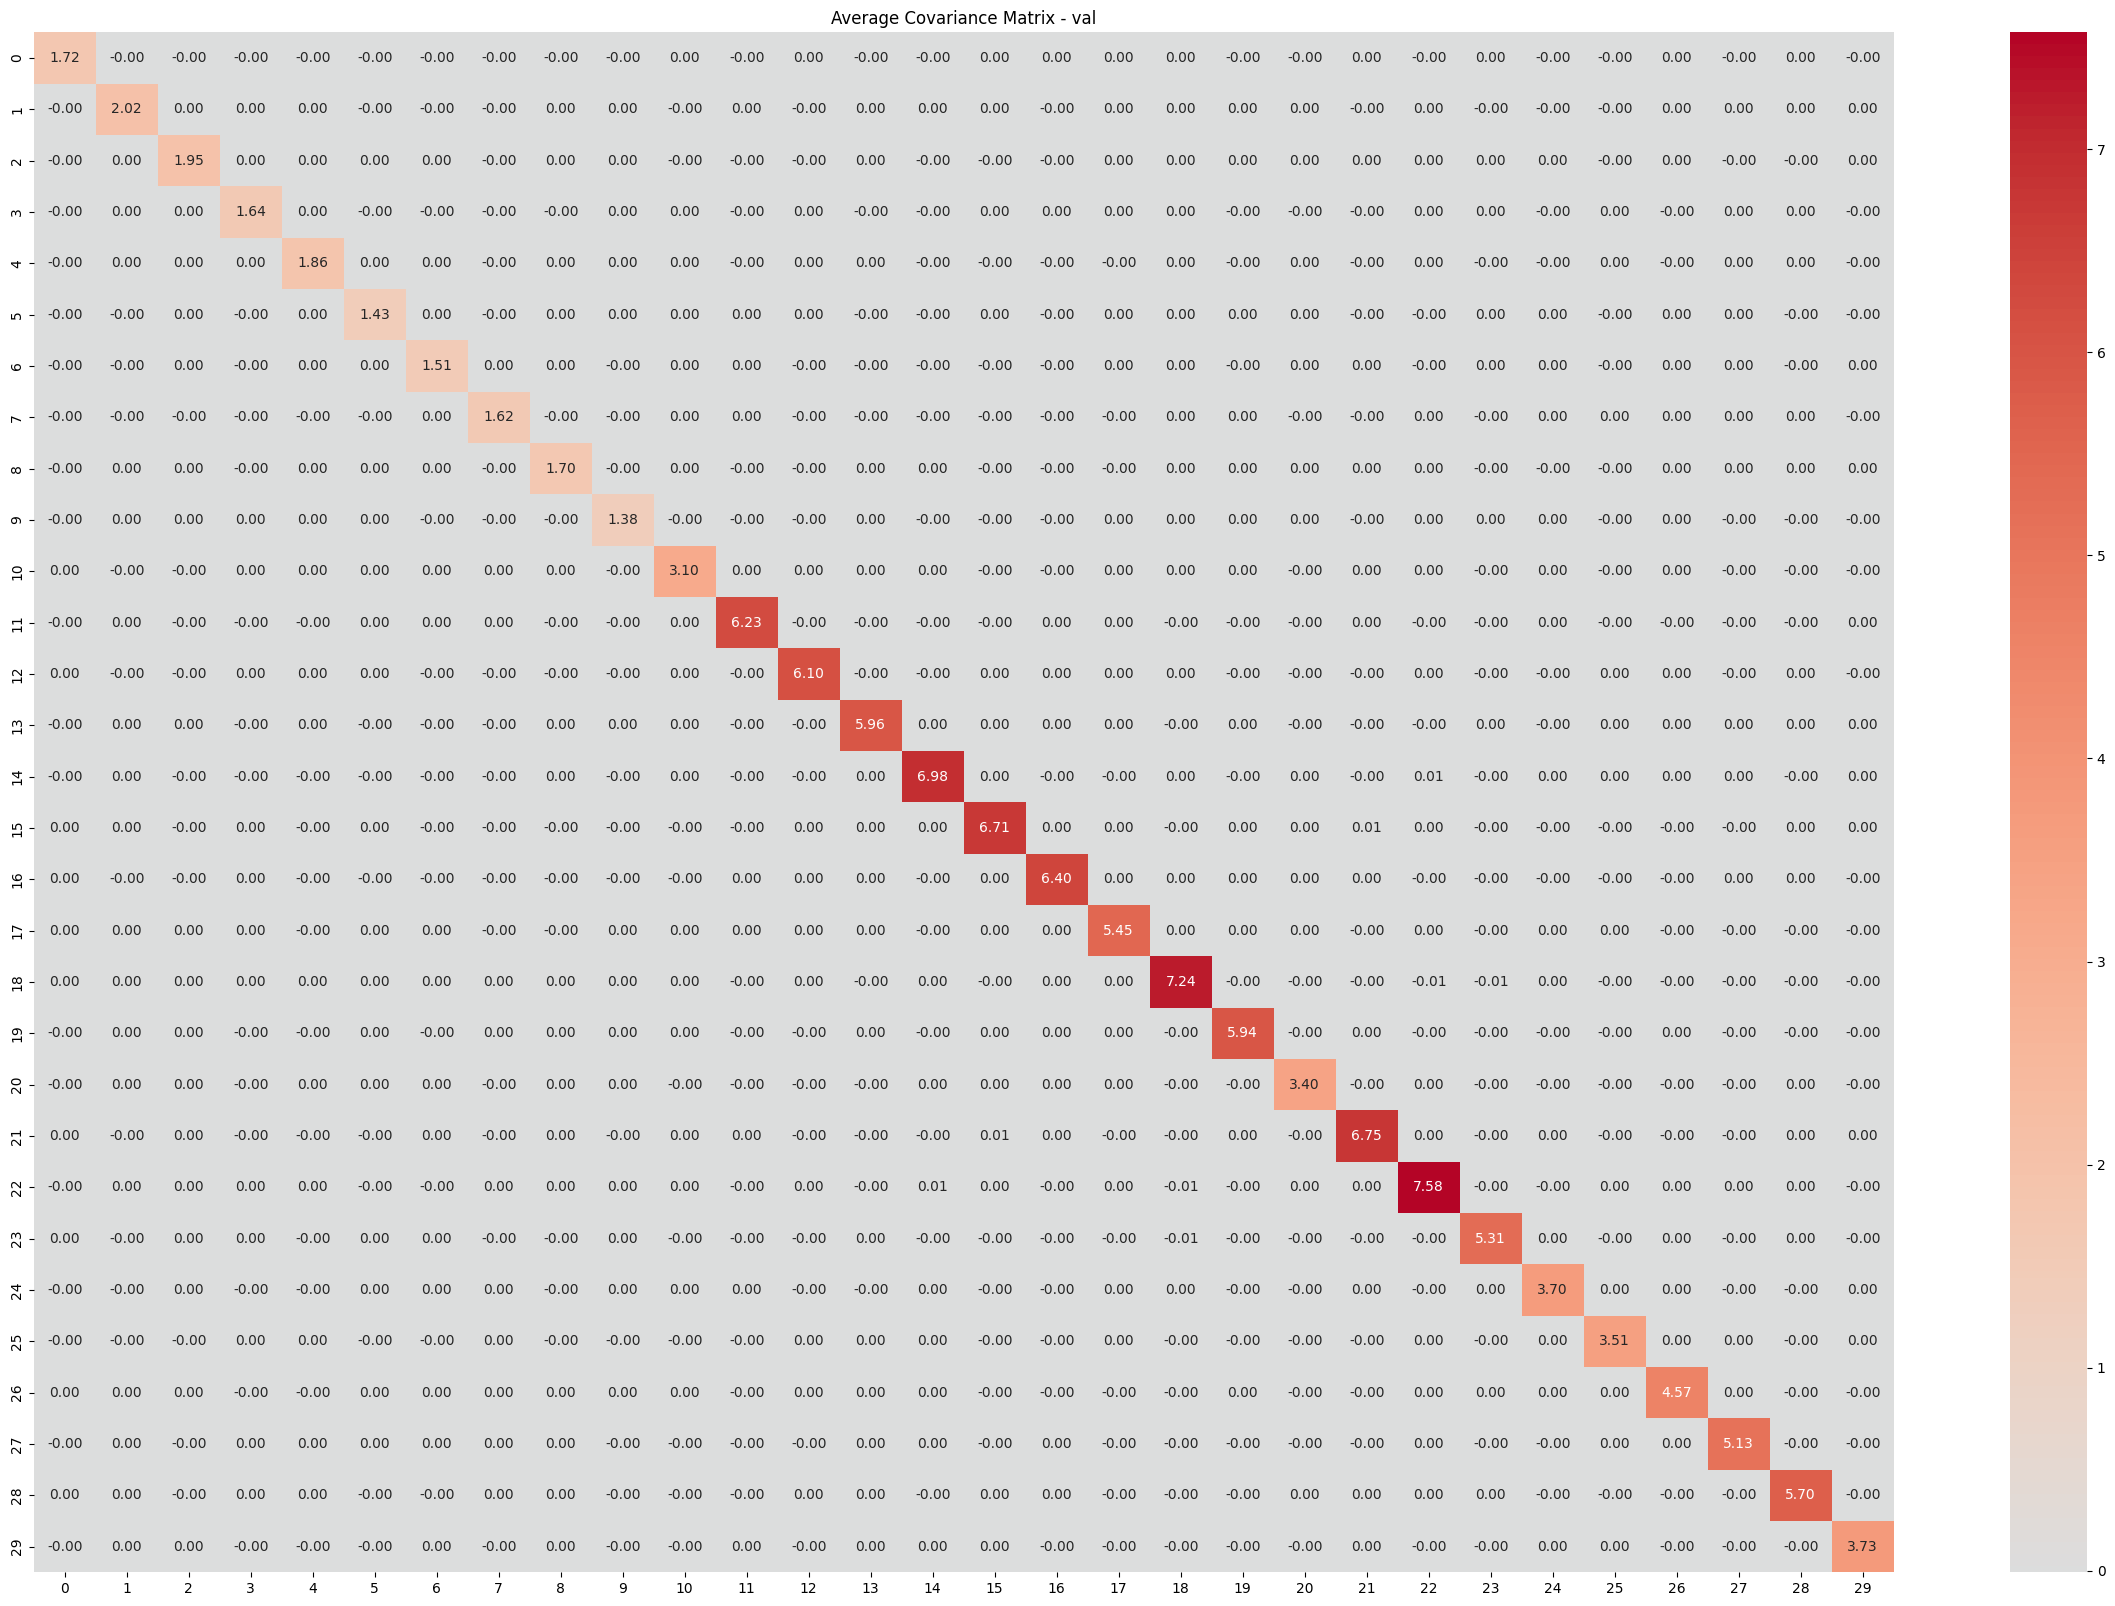

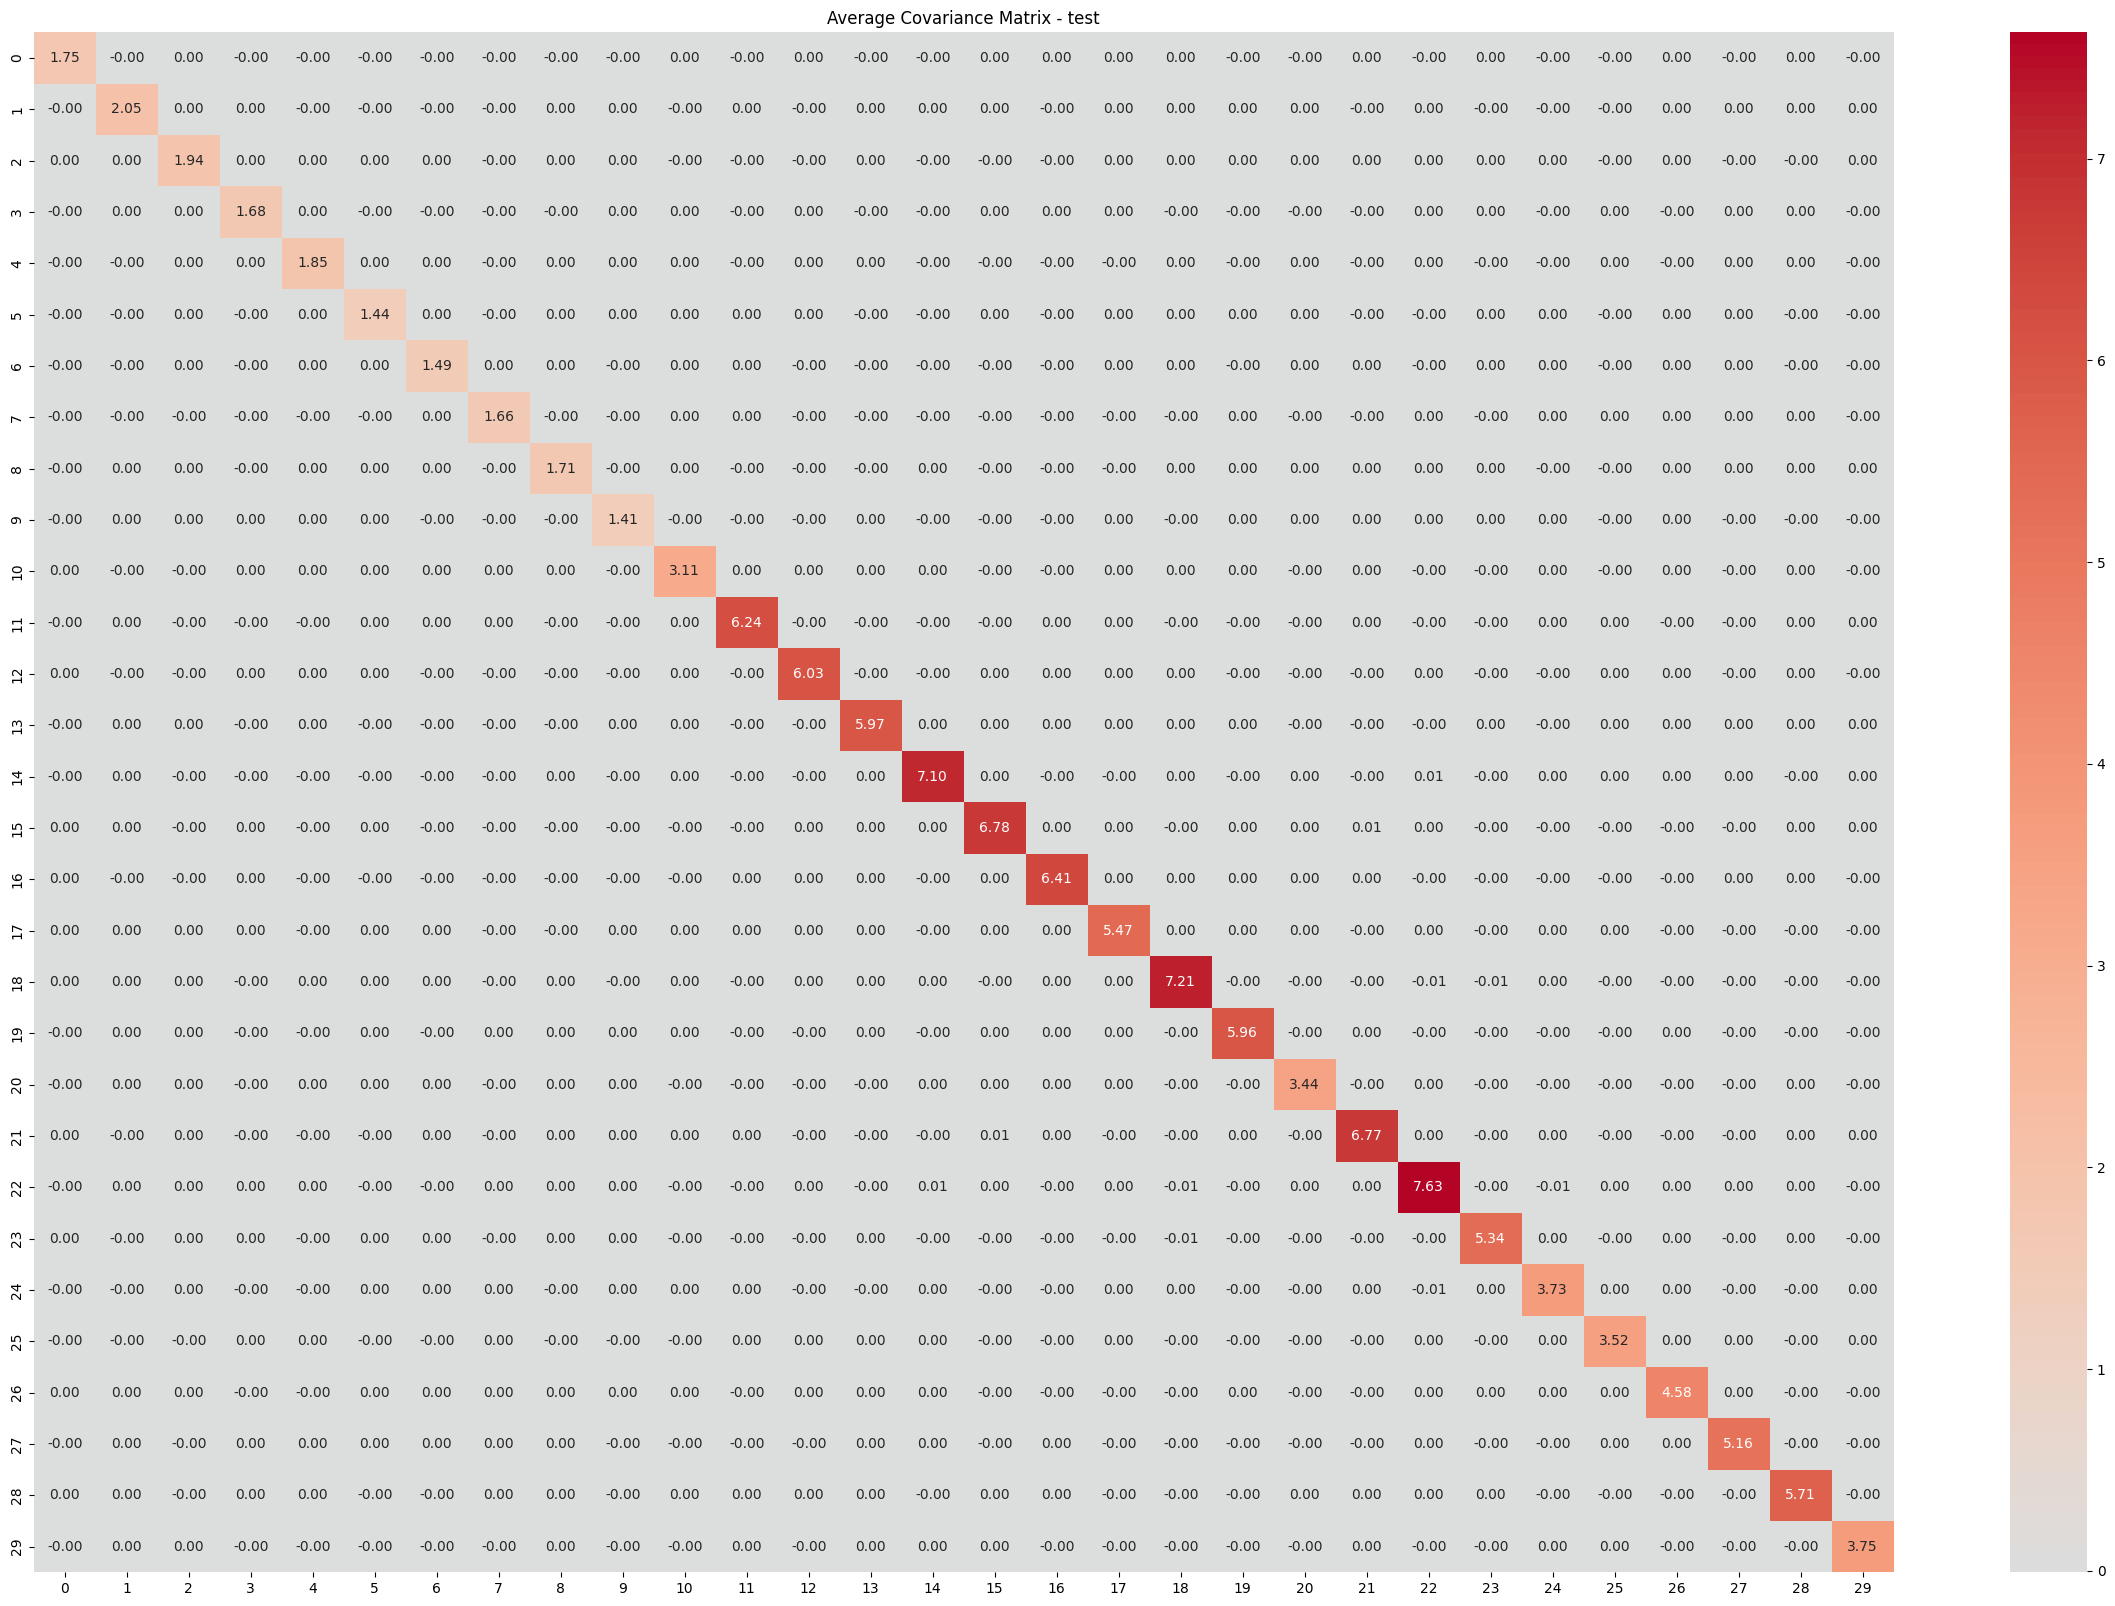

In [749]:
for split_name, data in splits.items():
    avg_cov = data["avg_model_covariance_matrix"]
    if avg_cov is not None:
        plt.figure(figsize=(30, 20))
        sns.heatmap(avg_cov, annot=True, fmt=".2f", cmap="coolwarm", center=0)
        plt.title(f"Average Covariance Matrix - {split_name}")
        plt.show()
        
        

        

# Model performance

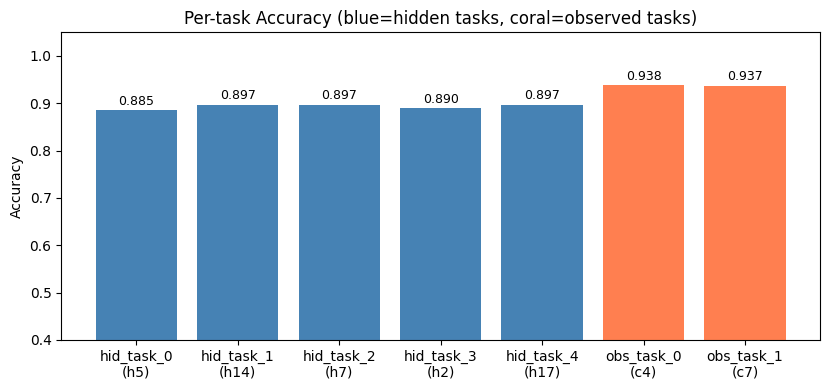

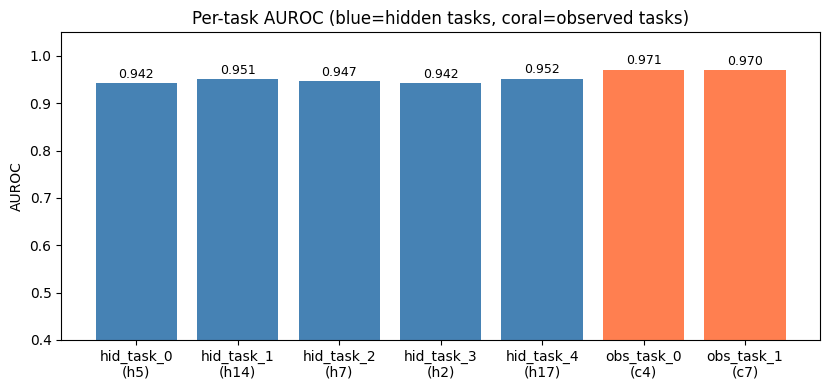

In [750]:
def get_model_performance(experiment_path, num_tasks):
    log_path = os.path.join(experiment_path, "log.txt")
    test_line = None
    with open(log_path, "r") as f:
        for line in f:
            if "Test" in line:
                test_line = line
    if test_line is None:
        raise ValueError("No 'Test' line found in log.txt")
    
    def get_metric(pattern, line, default=None):
        m = re.search(pattern, line)
        return float(m.group(1)) if m else default
    
    metrics = {}
    
    
    for k in range(num_tasks):
        metrics[f"y_auroc_task_{k}"] = get_metric(rf"y_auroc_task_{k}:\s*([0-9.]+)", test_line)
        metrics[f"y_accuracy_task_{k}"] = get_metric(rf"y_accuracy_task_{k}:\s*([0-9.]+)", test_line)
    return metrics
        
    
def plot_per_task_metric(
    metrics,
    metric_name="y_accuracy_task",
    ylabel=None,
    title=None,
    ylim=(0.4, 1.05),
):
    task_values = [metrics.get(f"{metric_name}_{k}") for k in range(num_tasks)]

    # Use 0 for missing values so no visible bar is plotted
    plot_values = [0.0 if v is None else v for v in task_values]

    task_labels = (
        [f"hid_task_{k}\n(h{hid_task_idx[k].item()})" for k in range(num_hid_tasks)]
        + [f"obs_task_{j}\n(c{obs_task_idx[j].item()})" for j in range(num_obs_tasks)]
    )
    colors = ["steelblue"] * num_hid_tasks + ["coral"] * num_obs_tasks

    display_name = {
        "y_accuracy_task": "Accuracy",
        "y_auroc_task": "AUROC",
        "y_ap_task": "Average Precision",
    }.get(metric_name, metric_name)

    fig, ax = plt.subplots(figsize=(max(6, num_tasks * 1.2), 4))
    bars = ax.bar(task_labels, plot_values, color=colors)

    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel or display_name)
    ax.set_title(title or f"Per-task {display_name} (blue=hidden tasks, coral=observed tasks)")

    for bar, v in zip(bars, task_values):
        if v is None:
            label = "nan"
            y_pos = ylim[0] + 0.005
        else:
            label = f"{v:.3f}"
            y_pos = bar.get_height() + 0.005

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            label,
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()
    
    
test_metrics = get_model_performance(EXPERIMENT_PATH, num_tasks=num_tasks)

plot_per_task_metric(test_metrics, metric_name="y_accuracy_task", ylim=(0.4, 1.05))
plot_per_task_metric(test_metrics, metric_name="y_auroc_task", ylim=(0.4, 1.05))
        
        
        

## Distributed probe — hidden concept recovery

Logistic regression on the full `res_mu` vector to predict each hidden concept. This is the upper bound on recoverable hidden-concept information from the residual channel. Task-bit concepts (hid_task_idx) should show high AUC; non-task-bit concepts should be near chance.

Hidden concept distributed probe (task bits highlighted):


,hidden_concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_hid,abs_w_hid,is_task_bit,hid_task_k
5,5,0.943099,0.8814,0.878757,0.974940,0.974940,True,0.0
14,14,0.950407,0.8938,0.892727,-0.952066,0.952066,True,1.0
7,7,0.950707,0.8969,0.894462,0.891934,0.891934,True,2.0
2,2,0.946829,0.8902,0.885768,-0.609588,0.609588,True,3.0
17,17,0.949796,0.8916,0.890814,0.549488,0.549488,True,4.0
0,0,0.590089,0.5683,0.565476,0.000000,0.000000,False,NaN
12,12,0.583562,0.5613,0.559051,0.000000,0.000000,False,NaN
18,18,0.587303,0.5623,0.556849,0.000000,0.000000,False,NaN
16,16,0.611781,0.5779,0.578532,0.000000,0.000000,False,NaN
15,15,0.580610,0.5608,0.554925,0.000000,0.000000,False,NaN


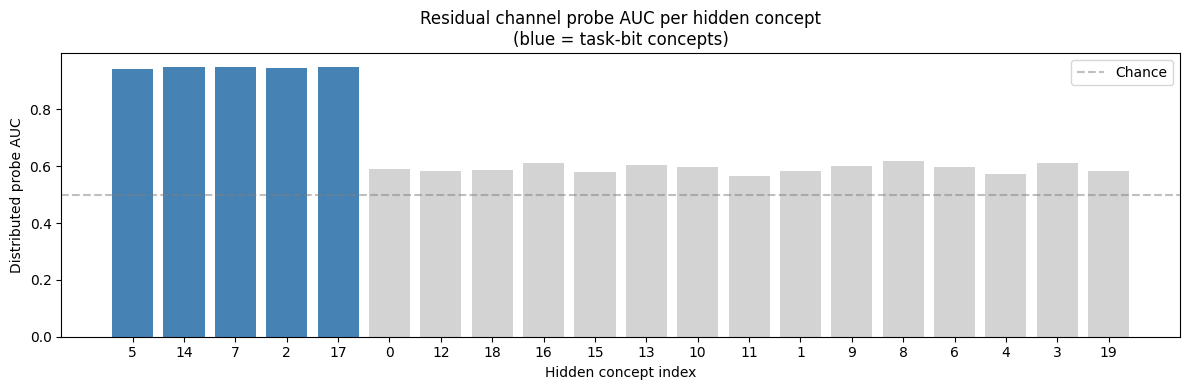

In [751]:
def probe_baseline(H_pred_train, H_true_train, H_pred_test, H_true_test,
                   column_name="hidden_concept_idx"):
    """Fit one logistic regression per column of H_true, evaluate on test set."""
    H_pred_train = to_numpy(H_pred_train).astype(float)
    H_pred_test = to_numpy(H_pred_test).astype(float)
    H_true_train = to_numpy(H_true_train).astype(float)
    H_true_test = to_numpy(H_true_test).astype(float)

    rows = []
    for h in range(H_true_train.shape[1]):
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
        )
        clf.fit(H_pred_train, H_true_train[:, h])
        probs = clf.predict_proba(H_pred_test)[:, 1]
        preds = (probs >= 0.5).astype(int)
        rows.append({
            column_name: h,
            "distributed_auc": roc_auc_score(H_true_test[:, h], probs),
            "distributed_accuracy": accuracy_score(H_true_test[:, h], preds),
            "distributed_f1": f1_score(H_true_test[:, h], preds),
        })
    return pd.DataFrame(rows)


# Hidden concepts from res_mu
probe_hidden = probe_baseline(
    splits["train"]["res_mu"], splits["train"]["hidden_residuals"],
    splits["test"]["res_mu"], splits["test"]["hidden_residuals"],
)

# Annotate with task weights and task membership
probe_hidden["w_hid"] = probe_hidden["hidden_concept_idx"].apply(lambda i: w_hid[i].item())
probe_hidden["abs_w_hid"] = probe_hidden["w_hid"].abs()
probe_hidden["is_task_bit"]= probe_hidden["hidden_concept_idx"].isin(hid_task_idx.tolist())
probe_hidden["hid_task_k"] = probe_hidden["hidden_concept_idx"].map(task_map_hid)
probe_hidden = probe_hidden.sort_values("abs_w_hid", ascending=False)

print("Hidden concept distributed probe (task bits highlighted):")
display(probe_hidden.head(20))

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))
colors_bar = ["steelblue" if is_tb else "lightgrey"
              for is_tb in probe_hidden["is_task_bit"]]
ax.bar(probe_hidden["hidden_concept_idx"].astype(str), probe_hidden["distributed_auc"],
       color=colors_bar)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Hidden concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Residual channel probe AUC per hidden concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


## Observed concept probe — ceiling reference

Logistic regression on `c_mu` to predict each observed concept. Provides the AUC ceiling: the residual task-bit probe should approach this.

Observed concept probe (task bits highlighted):


,concept_idx,distributed_auc,distributed_accuracy,distributed_f1,w_obs,abs_w_obs,is_task_bit
4,4,0.970342,0.9322,0.931432,0.930378,0.930378,True
7,7,0.972902,0.9349,0.934196,0.841165,0.841165,True
1,1,0.968817,0.9303,0.928652,0.621388,0.621388,False
0,0,0.968885,0.9301,0.928418,0.000000,0.000000,False
2,2,0.969372,0.9273,0.926035,0.000000,0.000000,False
3,3,0.966181,0.9233,0.921647,0.000000,0.000000,False
5,5,0.965306,0.9221,0.921527,0.000000,0.000000,False
6,6,0.970353,0.9333,0.932592,0.000000,0.000000,False
8,8,0.969876,0.9307,0.930498,0.000000,0.000000,False
9,9,0.968254,0.9273,0.926529,0.000000,0.000000,False


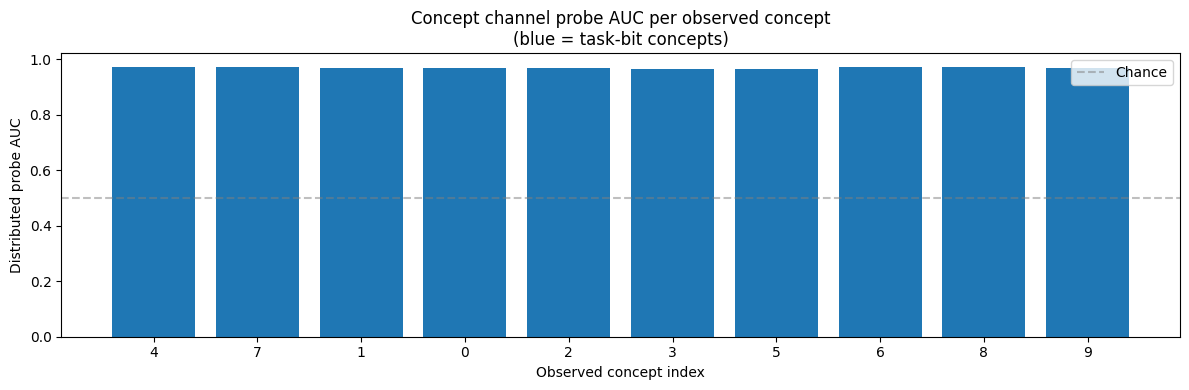

In [752]:
probe_observed = probe_baseline(
    splits["train"]["c_mu"], splits["train"]["concepts"],
    splits["test"]["c_mu"], splits["test"]["concepts"],
    column_name="concept_idx",
)
probe_observed["w_obs"] = probe_observed["concept_idx"].apply(lambda i: w_obs[i].item())
probe_observed["abs_w_obs"] = probe_observed["w_obs"].abs()
probe_observed["is_task_bit"]= probe_observed["concept_idx"].isin(obs_task_idx.tolist())
probe_observed = probe_observed.sort_values("abs_w_obs", ascending=False)

print("Observed concept probe (task bits highlighted):")
display(probe_observed)

# Bar chart: probe AUC per hidden concept, coloured by task membership
fig, ax = plt.subplots(figsize=(max(8, hid_dim * 0.6), 4))

ax.bar(probe_observed["concept_idx"].astype(str), probe_observed["distributed_auc"])
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.set_xlabel("Observed concept index")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Concept channel probe AUC per observed concept\n(blue = task-bit concepts)")
ax.legend()
plt.tight_layout()
plt.show()


# Predictive power of c_mu

In [753]:

R_train_raw = to_numpy(train_data["res_mu"]).astype(np.float32)
R_val_raw   = to_numpy(val_data["res_mu"]).astype(np.float32)
R_test_raw  = to_numpy(test_data["res_mu"]).astype(np.float32)

C_train_raw = to_numpy(train_data["c_mu"]).astype(np.float32)
C_val_raw   = to_numpy(val_data["c_mu"]).astype(np.float32)
C_test_raw  = to_numpy(test_data["c_mu"]).astype(np.float32)

Y_train = to_numpy(train_data["y"]).astype(np.float32)
Y_val   = to_numpy(val_data["y"]).astype(np.float32)
Y_test  = to_numpy(test_data["y"]).astype(np.float32)

In [754]:
# ============================================================
# Diagnostic 2: compare c_mu-only vs c_mu + res_mu probes
# ============================================================
# This measures the conditional value of the residual channel for each task.
#
# If adding res_mu gives a large improvement on hidden tasks, then res_mu
# contains task-relevant information beyond c_mu.
#
# If improvement is small, then c_mu already explains most task labels.

# NOTE: use the raw arrays from Block 2 (C_*_raw / R_*_raw) throughout --
# don't touch the standardized C_train / R_train that the atom model
# (Blocks 3-9) depends on. The probe pipelines standardize internally.

Xc_train = C_train_raw
Xc_test  = C_test_raw

Xcr_train = np.concatenate([C_train_raw, R_train_raw], axis=1)
Xcr_test  = np.concatenate([C_test_raw, R_test_raw], axis=1)

rows = []

for k in range(num_tasks):
    y_tr = Y_train[:, k]
    y_te = Y_test[:, k]

    # -----------------------------
    # c_mu-only classifier
    # -----------------------------
    clf_c = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    clf_c.fit(Xc_train, y_tr)

    scores_c = clf_c.decision_function(Xc_test)
    probs_c = clf_c.predict_proba(Xc_test)[:, 1]

    # -----------------------------
    # c_mu + res_mu classifier
    # -----------------------------
    clf_cr = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    clf_cr.fit(Xcr_train, y_tr)

    scores_cr = clf_cr.decision_function(Xcr_test)
    probs_cr = clf_cr.predict_proba(Xcr_test)[:, 1]

    # -----------------------------
    # Metrics
    # -----------------------------
    if len(np.unique(y_te)) == 2:
        auc_c = roc_auc_score(y_te, scores_c)
        auc_cr = roc_auc_score(y_te, scores_cr)

        bce_c = log_loss(y_te, probs_c, labels=[0, 1])
        bce_cr = log_loss(y_te, probs_cr, labels=[0, 1])

        ap_c = average_precision_score(y_te, scores_c)
        ap_cr = average_precision_score(y_te, scores_cr)
    else:
        auc_c = auc_cr = np.nan
        bce_c = bce_cr = np.nan
        ap_c = ap_cr = np.nan

    rows.append({
        "task": k,
        "task_type": "hidden_task" if k < num_hid_tasks else "observed_task",

        "auc_c_only": auc_c,
        "auc_c_plus_r": auc_cr,
        "delta_auc": auc_cr - auc_c,

        "bce_c_only": bce_c,
        "bce_c_plus_r": bce_cr,
        "delta_bce_improvement": bce_c - bce_cr,

        "ap_c_only": ap_c,
        "ap_c_plus_r": ap_cr,
        "delta_ap": ap_cr - ap_c,
    })


conditional_df = pd.DataFrame(rows)

print("Per-task conditional residual value:")
display(conditional_df)

print("\nMean by task type:")
display(
    conditional_df
    .groupby("task_type")[[
        "auc_c_only",
        "auc_c_plus_r",
        "delta_auc",
        "bce_c_only",
        "bce_c_plus_r",
        "delta_bce_improvement",
        "ap_c_only",
        "ap_c_plus_r",
        "delta_ap",
    ]]
    .mean()
)

Per-task conditional residual value:


,task,task_type,auc_c_only,auc_c_plus_r,delta_auc,bce_c_only,bce_c_plus_r,delta_bce_improvement,ap_c_only,ap_c_plus_r,delta_ap
0,0,hidden_task,0.508685,0.943028,0.434343,0.693106,0.291170,0.401936,0.502192,0.956936,0.454744
1,1,hidden_task,0.499893,0.953551,0.453658,0.693463,0.263116,0.430348,0.503346,0.965338,0.461993
2,2,hidden_task,0.512312,0.947670,0.435358,0.692909,0.279868,0.413041,0.516029,0.961702,0.445672
3,3,hidden_task,0.520483,0.944323,0.423840,0.692401,0.293413,0.398988,0.513689,0.957687,0.443998
4,4,hidden_task,0.512006,0.952446,0.440441,0.693036,0.270450,0.422587,0.507893,0.964456,0.456564
5,5,observed_task,0.970814,0.970137,-0.000677,0.282980,0.305888,-0.022908,0.979266,0.978745,-0.000521
6,6,observed_task,0.972132,0.971127,-0.001005,0.267657,0.287762,-0.020105,0.979931,0.979143,-0.000788



Mean by task type:


,auc_c_only,auc_c_plus_r,delta_auc,bce_c_only,bce_c_plus_r,delta_bce_improvement,ap_c_only,ap_c_plus_r,delta_ap
task_type,,,,,,,,,
hidden_task,0.510676,0.948204,0.437528,0.692983,0.279603,0.413380,0.508630,0.961224,0.452594
observed_task,0.971473,0.970632,-0.000841,0.275318,0.296825,-0.021507,0.979599,0.978944,-0.000655


## Raw axis AUC matrix — hidden concepts vs residual dimensions

Each cell = AUC of residual dimension r_j for predicting hidden concept h_i. Task-bit rows (hid_task_idx) should show elevated AUC; other rows should be ~0.5.

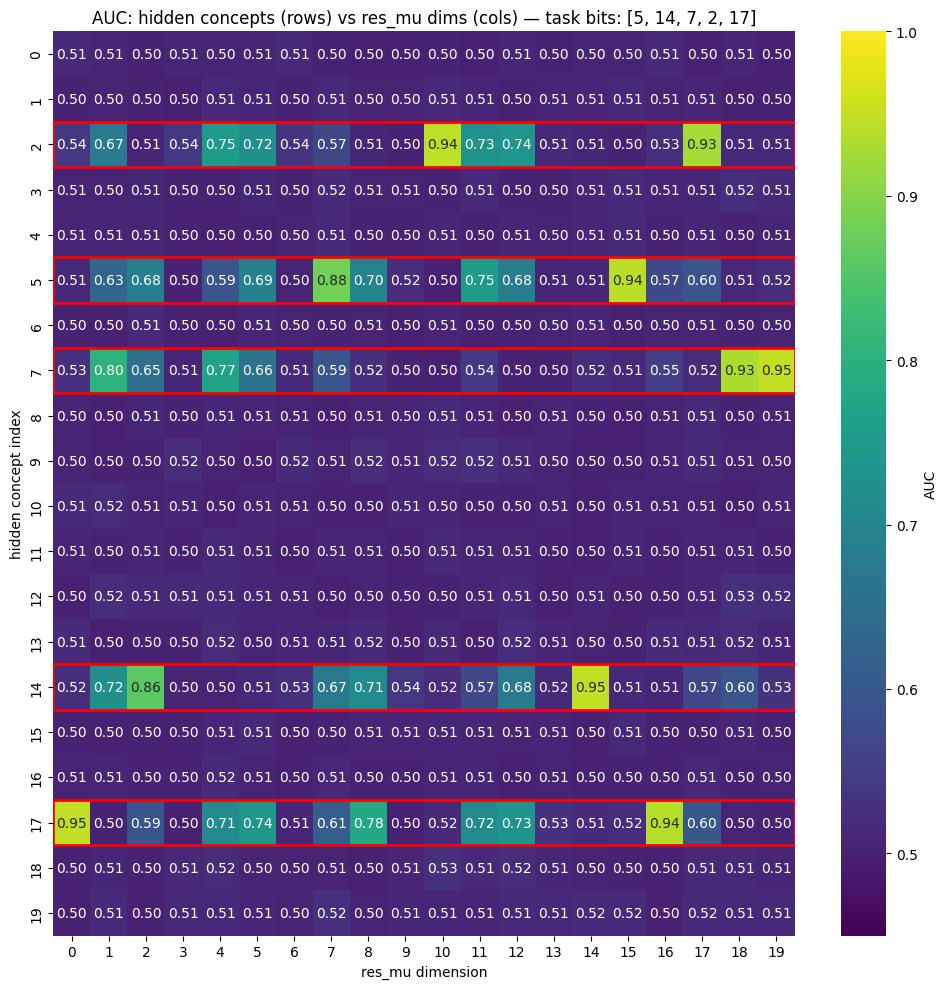

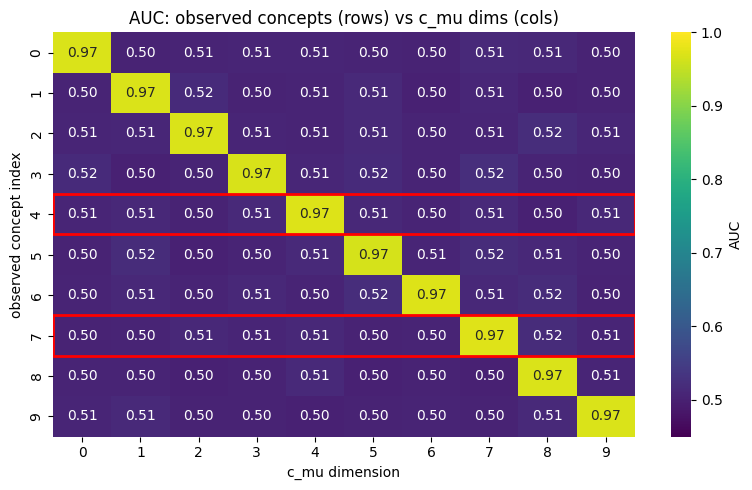

In [755]:
def auc_matrix(true_labels, pred_scores):
    """Compute AUC for every (row, col) pair. Shape: (n_true, n_pred)."""
    n_true = true_labels.shape[1]
    n_pred = pred_scores.shape[1]
    mat = np.zeros((n_true, n_pred))
    for i in range(n_true):
        for j in range(n_pred):
            if len(np.unique(true_labels[:, i])) > 1:
                mat[i, j] = calculate_auc(true_labels[:, i], pred_scores[:, j])
            else:
                mat[i, j] = np.nan
    return mat


def plot_heatmap(mat, title, x_label, y_label, annot=True,
                 highlight_rows=None, highlight_cols=None):
    fig, ax = plt.subplots(figsize=(max(8, mat.shape[1] * 0.5),
                                    max(5, mat.shape[0] * 0.5)))
    sns.heatmap(mat, annot=annot, fmt=".2f", cmap="viridis",
                vmin=0.45, vmax=1.0, ax=ax, cbar_kws={"label": "AUC"})
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if highlight_rows is not None:
        for r in highlight_rows:
            ax.add_patch(plt.Rectangle((0, r), mat.shape[1], 1,
                         fill=False, edgecolor="red", lw=2))
    plt.tight_layout()
    plt.show()


# Hidden concepts vs residual dimensions
auc_mat_hid_res = auc_matrix(
    to_numpy(test_data["hidden_residuals"]),
    to_numpy(test_data["res_mu"]),
)
plot_heatmap(
    auc_mat_hid_res,
    title=f"AUC: hidden concepts (rows) vs res_mu dims (cols) — task bits: {hid_task_idx.tolist()}",
    x_label="res_mu dimension",
    y_label="hidden concept index",
    highlight_rows=hid_task_idx.tolist(),
    annot=True,
)

# Observed concepts vs c_mu (ceiling reference)
auc_mat_obs_cmu = auc_matrix(
    to_numpy(test_data["concepts"]),
    to_numpy(test_data["c_mu"]),
)
plot_heatmap(
    auc_mat_obs_cmu,
    title="AUC: observed concepts (rows) vs c_mu dims (cols)",
    x_label="c_mu dimension",
    y_label="observed concept index",
    highlight_rows=obs_task_idx.tolist(),
    annot=True,
)


# Sparse atom model

In [756]:
# ============================================================
# Block 0-1: Imports
# ============================================================
# This block imports PyTorch for model training, NumPy for array handling,
# sklearn for AUROC evaluation, and matplotlib for visualizing learned atoms.

import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score
from scipy.optimize import linear_sum_assignment



def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

In [757]:
# ============================================================
# Block 2: Extract residual means, concept means, and labels
# ============================================================
# R = residual means, shape (n, 20)
# C = observed concept means, shape (n, 10)
# Y = multilabel targets, shape (n, T), where T = 7 in your case.

R_train_raw = to_numpy(train_data["res_mu"]).astype(np.float32)
R_val_raw   = to_numpy(val_data["res_mu"]).astype(np.float32)
R_test_raw  = to_numpy(test_data["res_mu"]).astype(np.float32)

C_train_raw = to_numpy(train_data["c_mu"]).astype(np.float32)
C_val_raw   = to_numpy(val_data["c_mu"]).astype(np.float32)
C_test_raw  = to_numpy(test_data["c_mu"]).astype(np.float32)

Y_train = to_numpy(train_data["y"]).astype(np.float32)
Y_val   = to_numpy(val_data["y"]).astype(np.float32)
Y_test  = to_numpy(test_data["y"]).astype(np.float32)

print("R_train:", R_train_raw.shape)
print("C_train:", C_train_raw.shape)
print("Y_train:", Y_train.shape)

R_train: (30000, 20)
C_train: (30000, 10)
Y_train: (30000, 7)


In [758]:
# ============================================================
# Block 3: Standardize r and c using train statistics
# ============================================================
# The atom model uses linear projections, so standardization matters.
# We fit means/stds only on train data and apply them to val/test.

eps = 1e-8

R_mean = R_train_raw.mean(axis=0, keepdims=True)
R_std  = R_train_raw.std(axis=0, keepdims=True) + eps

C_mean = C_train_raw.mean(axis=0, keepdims=True)
C_std  = C_train_raw.std(axis=0, keepdims=True) + eps

R_train = (R_train_raw - R_mean) / R_std
R_val   = (R_val_raw   - R_mean) / R_std
R_test  = (R_test_raw  - R_mean) / R_std

C_train = (C_train_raw - C_mean) / C_std
C_val   = (C_val_raw   - C_mean) / C_std
C_test  = (C_test_raw  - C_mean) / C_std

In [759]:
# ============================================================
# Block 4: Create PyTorch dataloaders
# ============================================================
# Each batch contains:
#   r: standardized residual means
#   c: standardized observed concept means
#   y: multilabel task targets

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

batch_size = 512

train_ds = TensorDataset(
    torch.tensor(R_train, dtype=torch.float32),
    torch.tensor(C_train, dtype=torch.float32),
    torch.tensor(Y_train, dtype=torch.float32),
)

val_ds = TensorDataset(
    torch.tensor(R_val, dtype=torch.float32),
    torch.tensor(C_val, dtype=torch.float32),
    torch.tensor(Y_val, dtype=torch.float32),
)

test_ds = TensorDataset(
    torch.tensor(R_test, dtype=torch.float32),
    torch.tensor(C_test, dtype=torch.float32),
    torch.tensor(Y_test, dtype=torch.float32),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Using device: cpu


In [760]:
# ============================================================
# Block 5: Define the decorrelation penalty
# ============================================================
# This encourages different atom activations z_j to be uncorrelated.
#
# Given batch activations Z of shape (batch_size, m), we compute their
# empirical correlation matrix and penalize off-diagonal entries.
#
# The penalty is:
#   sum_{i != j} Corr(z_i, z_j)^2

def offdiag_corr_penalty(Z, eps=1e-8):
    """
    Z: Tensor of shape (batch_size, m)
       Batch of atom activations.

    Returns:
       Scalar penalty measuring squared off-diagonal correlations.
    """

    # If there is only one atom, there is nothing to decorrelate.
    if Z.shape[1] <= 1:
        return torch.tensor(0.0, device=Z.device)

    # Center each atom activation over the batch.
    Z_centered = Z - Z.mean(dim=0, keepdim=True)

    # Normalize each atom activation to unit standard deviation.
    Z_std = Z_centered.std(dim=0, keepdim=True) + eps
    Z_norm = Z_centered / Z_std

    # Compute empirical correlation matrix.
    # Shape: (m, m)
    corr = (Z_norm.T @ Z_norm) / max(Z_norm.shape[0] - 1, 1)

    # Remove diagonal entries because Corr(z_j, z_j) = 1 by construction.
    offdiag = corr - torch.diag(torch.diag(corr))

    # Penalize squared off-diagonal correlations.
    return (offdiag ** 2).sum()

In [761]:
# ============================================================
# Block 6: Define the supervised sparse atom model
# ============================================================
# Model:
#
#   z = V^T r
#
#   logits_k = w_k^T c + beta_k^T z + b_k
#
# Parameters:
#   V: residual dictionary, shape (r_dim, m)
#   W_c: concept-path weights, shape (c_dim, T)
#   B: atom-task weights, shape (m, T)
#   b: task biases, shape (T,)
#
# Important:
#   The columns of V are normalized to unit norm in every forward pass.
#   This prevents scale cheating between V and B.

class SupervisedSparseAtoms(nn.Module):
    def __init__(self, r_dim, c_dim, num_tasks, m):
        super().__init__()

        # Store dimensions.
        self.r_dim = r_dim
        self.c_dim = c_dim
        self.num_tasks = num_tasks
        self.m = m

        # Raw residual dictionary.
        # Columns will be normalized during the forward pass.
        self.V_raw = nn.Parameter(torch.randn(r_dim, m) * 0.05)

        # Observed concept path weights.
        # This path is intentionally not L1-penalized.
        self.W_c = nn.Parameter(torch.randn(c_dim, num_tasks) * 0.01)

        # Residual atom path weights.
        # This matrix will be L1-penalized.
        self.B = nn.Parameter(torch.randn(m, num_tasks) * 0.01)

        # Per-task bias.
        self.b = nn.Parameter(torch.zeros(num_tasks))

    def normalized_V(self):
        """
        Returns column-normalized dictionary V.
        Each atom v_j has ||v_j||_2 = 1.
        """
        return F.normalize(self.V_raw, p=2, dim=0, eps=1e-8)

    def forward(self, r, c):
        """
        r: Tensor of shape (batch_size, r_dim)
        c: Tensor of shape (batch_size, c_dim)

        Returns:
          logits: Tensor of shape (batch_size, num_tasks)
          z:      Tensor of shape (batch_size, m)
          V:      Tensor of shape (r_dim, m)
        """

        # Normalize dictionary columns to fix atom scale.
        V = self.normalized_V()

        # Compute atom activations z = V^T r.
        # Since r has shape (batch, r_dim), this is r @ V.
        z = r @ V

        # Compute concept contribution c @ W_c.
        concept_logits = c @ self.W_c

        # Compute residual atom contribution z @ B.
        atom_logits = z @ self.B

        # Combine both paths and add bias.
        logits = concept_logits + atom_logits + self.b

        return logits, z, V

In [762]:
# ============================================================
# Block 7: Evaluation helpers
# ============================================================
# These functions compute validation/test BCE and multilabel AUROC.

@torch.no_grad()
def evaluate_task_metrics(model, loader):
    """
    Computes mean BCE and macro task AUROC on a dataloader.
    """

    model.eval()

    all_logits = []
    all_y = []

    total_bce = 0.0
    total_n = 0

    bce_fn = nn.BCEWithLogitsLoss(reduction="sum")

    for r, c, y in loader:
        r = r.to(device)
        c = c.to(device)
        y = y.to(device)

        logits, _, _ = model(r, c)
        # In case train on just hidden tasks
        y = y[:, : logits.shape[1]]    

        total_bce += bce_fn(logits, y).item()
        total_n += y.numel()

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits_np = torch.cat(all_logits, dim=0).numpy()
    y_np = torch.cat(all_y, dim=0).numpy()

    # Compute probabilities from logits using the sigmoid function.
    probs_np = 1.0 / (1.0 + np.exp(-logits_np))

    aucs = []
    for k in range(y_np.shape[1]):
        # AUROC is undefined if a task has only one class in the split.
        if len(np.unique(y_np[:, k])) == 2:
            aucs.append(roc_auc_score(y_np[:, k], probs_np[:, k]))

    mean_auc = float(np.mean(aucs)) if len(aucs) > 0 else np.nan
    mean_bce = total_bce / total_n

    return mean_bce, mean_auc

In [763]:
# ============================================================
# Block 8: Training function
# ============================================================
# This trains the model for one hyperparameter configuration.
#
# Objective:
#
#   task BCE
#   + lambda_B * ||B||_1
#   + lambda_dec * decorrelation(z)
#
# Early stopping is based on validation BCE without regularization.

def train_sparse_atoms(
    m=5,
    lambda_B=1e-3,
    lambda_dec=1.0,
    lr=1e-3,
    max_epochs=300,
    patience=30,
    verbose=True,
    seed=0,
    train_only_hidden_tasks=False,
):
    """
    Trains supervised sparse atoms.

    Returns:
      best_model: trained model with best validation BCE
      history: dictionary of training curves
    """

    # Set seeds for reproducibility.
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Infer dimensions from data.
    r_dim = R_train.shape[1]
    c_dim = C_train.shape[1]
    if train_only_hidden_tasks:
        num_tasks = num_hid_tasks
    else:
        num_tasks = num_hid_tasks + num_obs_tasks
    print(f"num_tasks = {num_tasks} (train_only_hidden_tasks={train_only_hidden_tasks})")
    # Initialize model.
    model = SupervisedSparseAtoms(
        r_dim=r_dim,
        c_dim=c_dim,
        num_tasks=num_tasks,
        m=m,
    ).to(device)

    # Optimizer.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Task loss.
    bce_fn = nn.BCEWithLogitsLoss()

    # Track best validation model.
    best_val_bce = float("inf")
    best_state = None
    epochs_without_improvement = 0

    # Store training curves.
    history = {
        "train_total_loss": [],
        "train_task_bce": [],
        "train_l1_B": [],
        "train_decorr": [],
        "val_bce": [],
        "val_auc": [],
    }

    for epoch in range(max_epochs):
        model.train()

        total_losses = []
        task_losses = []
        l1_losses = []
        dec_losses = []

        for r, c, y in train_loader:
            r = r.to(device)
            c = c.to(device)
            y = y.to(device)
            if train_only_hidden_tasks:
                y = y[:, :num_tasks]

            # Forward pass.
            logits, z, _ = model(r, c)

            # Main multilabel prediction loss.
            task_loss = bce_fn(logits, y)

            # L1 penalty on atom-task weights B.
            l1_B = model.B.abs().sum()

            # Decorrelation penalty on atom activations.
            decorr = offdiag_corr_penalty(z)

            # Full objective.
            loss = task_loss + lambda_B * l1_B + lambda_dec * decorr

            # Gradient update.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Store batch losses.
            total_losses.append(loss.item())
            task_losses.append(task_loss.item())
            l1_losses.append(l1_B.item())
            dec_losses.append(decorr.item())

        # Compute validation metrics.
        val_bce, val_auc = evaluate_task_metrics(model, val_loader)

        # Store epoch-level metrics.
        history["train_total_loss"].append(float(np.mean(total_losses)))
        history["train_task_bce"].append(float(np.mean(task_losses)))
        history["train_l1_B"].append(float(np.mean(l1_losses)))
        history["train_decorr"].append(float(np.mean(dec_losses)))
        history["val_bce"].append(val_bce)
        history["val_auc"].append(val_auc)

        # Early stopping on validation BCE.
        if val_bce < best_val_bce:
            best_val_bce = val_bce
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Print progress occasionally.
        if verbose and (epoch % 25 == 0 or epoch == max_epochs - 1):
            print(
                f"epoch={epoch:03d} | "
                f"train_bce={history['train_task_bce'][-1]:.4f} | "
                f"l1_B={history['train_l1_B'][-1]:.4f} | "
                f"decorr={history['train_decorr'][-1]:.4f} | "
                f"val_bce={val_bce:.4f} | "
                f"val_auc={val_auc:.4f}"
            )

        # Stop if validation BCE has not improved for a while.
        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch}. Best val BCE = {best_val_bce:.4f}")
            break

    # Restore best validation checkpoint.
    model.load_state_dict(best_state)

    return model, history

In [764]:
# ============================================================
# Block 9: Train one model
# ============================================================
# Start with m=8 because you have five task-relevant hidden concepts,
# but a few extra atoms can absorb nuisance or imperfectly separated structure.

model, history = train_sparse_atoms(
    m=7,
    lambda_B=3e-2,
    lambda_dec=1.0,
    lr=1e-3,
    max_epochs=300,
    patience=100,
    verbose=True,
    seed=0,
    train_only_hidden_tasks=False
    
)

test_bce, test_auc = evaluate_task_metrics(model, test_loader)
print(f"Test BCE:  {test_bce:.4f}")
print(f"Test AUROC:{test_auc:.4f}")

num_tasks = 7 (train_only_hidden_tasks=False)
epoch=000 | train_bce=0.6775 | l1_B=0.3072 | decorr=1.8025 | val_bce=0.6656 | val_auc=0.8385
epoch=025 | train_bce=0.3434 | l1_B=4.5634 | decorr=0.0934 | val_bce=0.3677 | val_auc=0.9534
epoch=050 | train_bce=0.2949 | l1_B=4.2444 | decorr=0.0906 | val_bce=0.3286 | val_auc=0.9552
epoch=075 | train_bce=0.2763 | l1_B=4.2281 | decorr=0.0954 | val_bce=0.3166 | val_auc=0.9552
epoch=100 | train_bce=0.2675 | l1_B=4.2211 | decorr=0.1003 | val_bce=0.3132 | val_auc=0.9552
epoch=125 | train_bce=0.2623 | l1_B=4.2212 | decorr=0.0908 | val_bce=0.3132 | val_auc=0.9551
epoch=150 | train_bce=0.2590 | l1_B=4.2241 | decorr=0.0933 | val_bce=0.3149 | val_auc=0.9552
epoch=175 | train_bce=0.2569 | l1_B=4.2201 | decorr=0.0918 | val_bce=0.3179 | val_auc=0.9552
epoch=200 | train_bce=0.2558 | l1_B=4.2135 | decorr=0.0908 | val_bce=0.3217 | val_auc=0.9552
Early stopping at epoch 216. Best val BCE = 0.3127
Test BCE:  0.3122
Test AUROC:0.9548


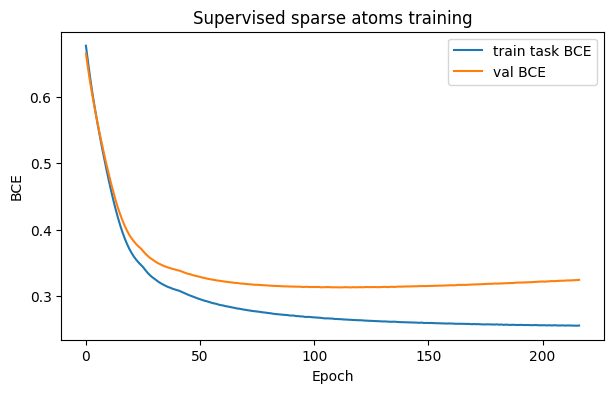

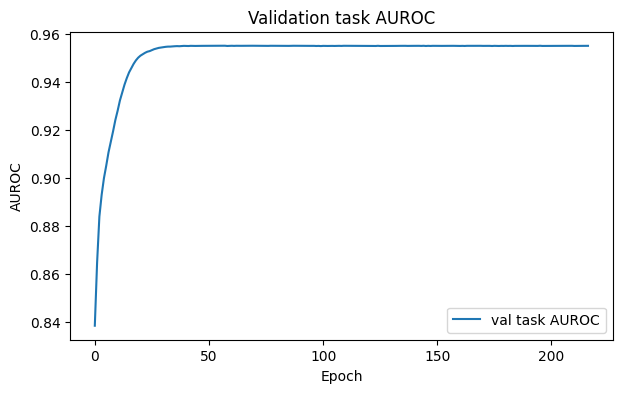

In [765]:
# ============================================================
# Block 10: Plot training curves
# ============================================================
# This helps check whether training is stable and whether validation BCE improves.

plt.figure(figsize=(7, 4))
plt.plot(history["train_task_bce"], label="train task BCE")
plt.plot(history["val_bce"], label="val BCE")
plt.xlabel("Epoch")
plt.ylabel("BCE")
plt.title("Supervised sparse atoms training")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["val_auc"], label="val task AUROC")
plt.xlabel("Epoch")
plt.ylabel("AUROC")
plt.title("Validation task AUROC")
plt.legend()
plt.show()

In [766]:
# ============================================================
# Block 11: Extract learned atom activations on train/test
# ============================================================
# After training, compute:
#
#   z = V^T r
#
# These are the learned residual atom activations.

@torch.no_grad()
def get_atom_activations(model, R, C, batch_size=2048):
    """
    Computes atom activations z for a full dataset.
    """

    model.eval()

    R_tensor = torch.tensor(R, dtype=torch.float32)
    C_tensor = torch.tensor(C, dtype=torch.float32)

    ds = TensorDataset(R_tensor, C_tensor)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_z = []

    for r, c in loader:
        r = r.to(device)
        c = c.to(device)

        _, z, _ = model(r, c)
        all_z.append(z.detach().cpu())

    return torch.cat(all_z, dim=0).numpy()


Z_train = get_atom_activations(model, R_train, C_train)
Z_test  = get_atom_activations(model, R_test, C_test)

print("Z_train:", Z_train.shape)
print("Z_test:", Z_test.shape)

Z_train: (30000, 7)
Z_test: (10000, 7)


In [767]:
# ============================================================
# Block 12: Compute AUC matrix between atoms and hidden concepts
# ============================================================
# This evaluates whether each learned atom corresponds to a ground-truth
# hidden concept.
#
# We use sign-invariant AUC:
#
#   max(AUC(z_j, h_l), 1 - AUC(z_j, h_l))
#
# because atom signs are arbitrary.

def auc_matrix_sign_invariant(binary_labels, scores):
    """
    binary_labels: shape (n, L), e.g. hidden concepts
    scores:        shape (n, M), e.g. atom activations

    Returns:
      aucs: shape (L, M)
    """

    binary_labels = np.asarray(binary_labels)
    scores = np.asarray(scores)

    L = binary_labels.shape[1]
    M = scores.shape[1]

    aucs = np.full((L, M), np.nan)

    for l in range(L):
        y = binary_labels[:, l]

        # Skip concepts that have only one class.
        if len(np.unique(y)) < 2:
            continue

        for j in range(M):
            s = scores[:, j]

            auc = roc_auc_score(y, s)

            # Sign-invariant version.
            aucs[l, j] = max(auc, 1.0 - auc)

    return aucs

In [768]:
# ============================================================
# Block 13: Load hidden concept labels and evaluate atoms
# ============================================================
# Change the key below if your hidden concept labels have a different name.
#
# Common alternatives might be:
#   "hidden_concepts"
#   "hidden_signal"
#   "hidden_residuals"
#   "c_hid"

H_test = to_numpy(test_data["hidden_residuals"]).astype(np.float32)

auc_atoms_hidden = auc_matrix_sign_invariant(H_test, Z_test)

print("Atom-hidden AUC matrix:", auc_atoms_hidden.shape)
print("Best AUC per hidden concept:")
print(np.nanmax(auc_atoms_hidden, axis=1))

Atom-hidden AUC matrix: (20, 7)
Best AUC per hidden concept:
[0.51096172 0.51205122 0.94551774 0.51676616 0.50948186 0.94327874
 0.50672931 0.94343382 0.50920044 0.51661699 0.50759757 0.51213221
 0.52399116 0.51653448 0.94991578 0.50943828 0.50935054 0.94903097
 0.52262069 0.52013941]


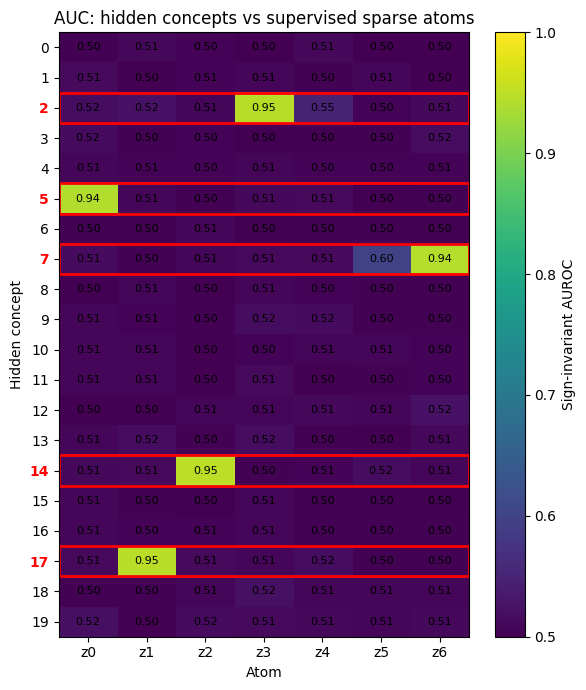

In [769]:
# ============================================================
# Block 14: Plot AUC heatmap: hidden concepts vs learned atoms
# ============================================================
# Rows are hidden concepts.
# Columns are learned atoms.
#
# Ideally, task-relevant hidden concepts should have one strong atom each.

def plot_auc_heatmap(auc_mat, title, x_label="Atom", y_label="Hidden concept", highlight_rows=None):
    plt.figure(figsize=(max(6, auc_mat.shape[1] * 0.8), max(5, auc_mat.shape[0] * 0.35)))
    plt.imshow(auc_mat, aspect="auto", vmin=0.5, vmax=1.0)
    plt.colorbar(label="Sign-invariant AUROC")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    plt.xticks(np.arange(auc_mat.shape[1]), [f"z{j}" for j in range(auc_mat.shape[1])])
    plt.yticks(np.arange(auc_mat.shape[0]), [str(i) for i in range(auc_mat.shape[0])])

    for i in range(auc_mat.shape[0]):
        for j in range(auc_mat.shape[1]):
            val = auc_mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
                
    if highlight_rows is not None:
        for r in highlight_rows:
            plt.gca().add_patch(plt.Rectangle((-0.5, r - 0.5), auc_mat.shape[1], 1,
                                              fill=False, edgecolor="red", lw=2))
        for tick in plt.gca().get_yticklabels():
            if int(tick.get_text()) in highlight_rows:
                tick.set_color("red")
                tick.set_fontweight("bold")

    plt.tight_layout()
    plt.show()


plot_auc_heatmap(
    auc_atoms_hidden,
    title="AUC: hidden concepts vs supervised sparse atoms",
    highlight_rows=hid_task_idx.tolist()
)

In [770]:
# ============================================================
# Block 15: Hungarian matching for task-relevant hidden concepts
# ============================================================
# If you know the task-relevant hidden concepts, use them here.


# Select only task-relevant rows from the AUC matrix.
auc_relevant = auc_atoms_hidden[hid_task_idx, :]

# Hungarian matching maximizes total AUC.
# scipy minimizes cost, so use negative AUC as cost.
row_ind, col_ind = linear_sum_assignment(-auc_relevant)

matched_hidden = hid_task_idx[row_ind]
matched_atoms = col_ind
matched_aucs = auc_relevant[row_ind, col_ind]

print("Hungarian matching: hidden concept -> atom")
for h, z_j, auc in zip(matched_hidden, matched_atoms, matched_aucs):
    print(f"h_{h:02d} -> z_{z_j:02d} | AUC = {auc:.3f}")

print(f"Mean matched AUC: {matched_aucs.mean():.3f}")

Hungarian matching: hidden concept -> atom
h_05 -> z_00 | AUC = 0.943
h_14 -> z_02 | AUC = 0.950
h_07 -> z_06 | AUC = 0.943
h_02 -> z_03 | AUC = 0.946
h_17 -> z_01 | AUC = 0.949
Mean matched AUC: 0.946


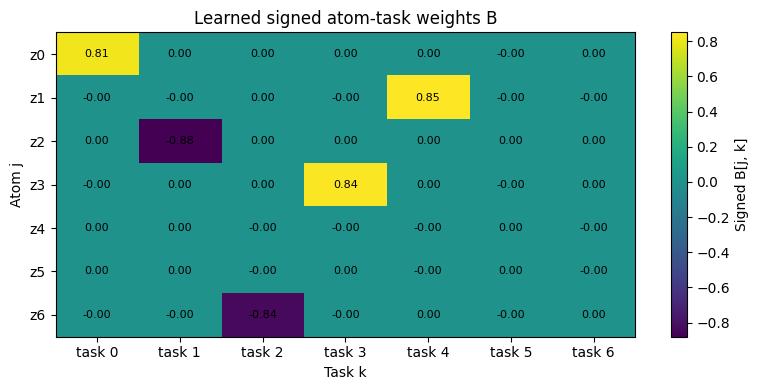

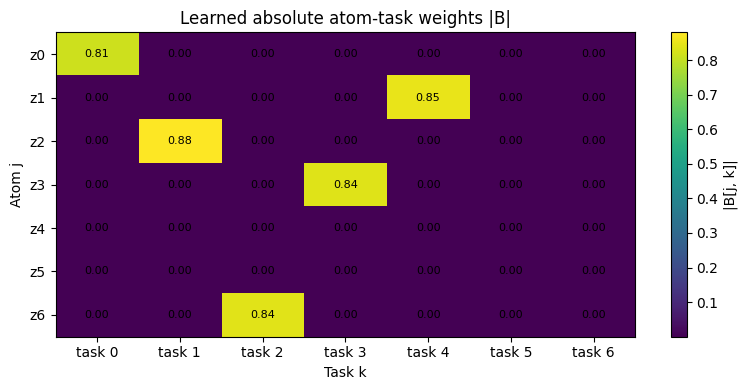

In [771]:
# ============================================================
# Block 16: Inspect learned B matrix
# ============================================================
# B[j, k] tells us how much atom j contributes to task k.
#
# If the model worked, tasks 0,...,4 should connect sparsely to atoms
# matching h_5, h_14, h_7, h_2, h_17.

B = model.B.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.imshow(B, aspect="auto")
plt.colorbar(label="Signed B[j, k]")
plt.xlabel("Task k")
plt.ylabel("Atom j")
plt.title("Learned signed atom-task weights B")
plt.xticks(np.arange(B.shape[1]), [f"task {k}" for k in range(B.shape[1])])
plt.yticks(np.arange(B.shape[0]), [f"z{j}" for j in range(B.shape[0])])

for j in range(B.shape[0]):
    for k in range(B.shape[1]):
        plt.text(k, j, f"{B[j, k]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.imshow(np.abs(B), aspect="auto")
plt.colorbar(label="|B[j, k]|")
plt.xlabel("Task k")
plt.ylabel("Atom j")
plt.title("Learned absolute atom-task weights |B|")
plt.xticks(np.arange(B.shape[1]), [f"task {k}" for k in range(B.shape[1])])
plt.yticks(np.arange(B.shape[0]), [f"z{j}" for j in range(B.shape[0])])

for j in range(B.shape[0]):
    for k in range(B.shape[1]):
        plt.text(k, j, f"{abs(B[j, k]):.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

In [772]:
print("Hidden concept weights (K task bits highlighted):")
display(df_w_hid)

print(f"task_map_obs: {task_map_obs}")
df_w_obs["obs_task_j"] = df_w_obs["observed_concept_idx"].map(task_map_obs)

print("\nObserved concept weights (J task bits highlighted):")
display(df_w_obs)

Hidden concept weights (K task bits highlighted):


,hidden_concept_idx,weight,abs_weight,is_task_bit,hid_task_k
5,5,0.974940,0.974940,True,0
14,14,-0.952066,0.952066,True,1
7,7,0.891934,0.891934,True,2
2,2,-0.609588,0.609588,True,3
17,17,0.549488,0.549488,True,4


task_map_obs: {4: 0, 7: 1}

Observed concept weights (J task bits highlighted):


,observed_concept_idx,weight,abs_weight,is_task_bit,obs_task_j
4,4,0.930378,0.930378,True,0.0
7,7,0.841165,0.841165,True,1.0
1,1,0.621388,0.621388,False,NaN


In [773]:
# ============================================================
# Block 17: Compare matched atoms with learned task wiring
# ============================================================
# This checks whether the atom aligned with h_l is actually used by
# the task that depends on h_l.
#


print("Matched hidden concept, matched atom, true task, |B[atom, task]|")
for h, z_j, auc in zip(matched_hidden, matched_atoms, matched_aucs):
    task_k = task_map_hid[int(h)]
    print(
        f"h_{int(h):02d} -> z_{int(z_j):02d} | "
        f"task={task_k} | "
        f"AUC={auc:.3f} | "
        f"|B|={abs(B[int(z_j), task_k]):.3f}"
    )

Matched hidden concept, matched atom, true task, |B[atom, task]|
h_05 -> z_00 | task=0 | AUC=0.943 | |B|=0.814
h_14 -> z_02 | task=1 | AUC=0.950 | |B|=0.880
h_07 -> z_06 | task=2 | AUC=0.943 | |B|=0.839
h_02 -> z_03 | task=3 | AUC=0.946 | |B|=0.838
h_17 -> z_01 | task=4 | AUC=0.949 | |B|=0.851


# Predictive power of c_mu

In [774]:
# ============================================================
# Diagnostic 2: compare c_mu-only vs c_mu + res_mu probes
# ============================================================
# This measures the conditional value of the residual channel for each task.
#
# If adding res_mu gives a large improvement on hidden tasks, then res_mu
# contains task-relevant information beyond c_mu.
#
# If improvement is small, then c_mu already explains most task labels.

# NOTE: use the raw arrays from Block 2 (C_*_raw / R_*_raw) throughout --
# don't touch the standardized C_train / R_train that the atom model
# (Blocks 3-9) depends on. The probe pipelines standardize internally.

Xc_train = C_train_raw
Xc_test  = C_test_raw

Xcr_train = np.concatenate([C_train_raw, R_train_raw], axis=1)
Xcr_test  = np.concatenate([C_test_raw, R_test_raw], axis=1)

rows = []

for k in range(num_tasks):
    y_tr = Y_train[:, k]
    y_te = Y_test[:, k]

    # -----------------------------
    # c_mu-only classifier
    # -----------------------------
    clf_c = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    clf_c.fit(Xc_train, y_tr)

    scores_c = clf_c.decision_function(Xc_test)
    probs_c = clf_c.predict_proba(Xc_test)[:, 1]

    # -----------------------------
    # c_mu + res_mu classifier
    # -----------------------------
    clf_cr = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
    clf_cr.fit(Xcr_train, y_tr)

    scores_cr = clf_cr.decision_function(Xcr_test)
    probs_cr = clf_cr.predict_proba(Xcr_test)[:, 1]

    # -----------------------------
    # Metrics
    # -----------------------------
    if len(np.unique(y_te)) == 2:
        auc_c = roc_auc_score(y_te, scores_c)
        auc_cr = roc_auc_score(y_te, scores_cr)

        bce_c = log_loss(y_te, probs_c, labels=[0, 1])
        bce_cr = log_loss(y_te, probs_cr, labels=[0, 1])

        ap_c = average_precision_score(y_te, scores_c)
        ap_cr = average_precision_score(y_te, scores_cr)
    else:
        auc_c = auc_cr = np.nan
        bce_c = bce_cr = np.nan
        ap_c = ap_cr = np.nan

    rows.append({
        "task": k,
        "task_type": "hidden_task" if k < num_hid_tasks else "observed_task",

        "auc_c_only": auc_c,
        "auc_c_plus_r": auc_cr,
        "delta_auc": auc_cr - auc_c,

        "bce_c_only": bce_c,
        "bce_c_plus_r": bce_cr,
        "delta_bce_improvement": bce_c - bce_cr,

        "ap_c_only": ap_c,
        "ap_c_plus_r": ap_cr,
        "delta_ap": ap_cr - ap_c,
    })


conditional_df = pd.DataFrame(rows)

print("Per-task conditional residual value:")
display(conditional_df)

print("\nMean by task type:")
display(
    conditional_df
    .groupby("task_type")[[
        "auc_c_only",
        "auc_c_plus_r",
        "delta_auc",
        "bce_c_only",
        "bce_c_plus_r",
        "delta_bce_improvement",
        "ap_c_only",
        "ap_c_plus_r",
        "delta_ap",
    ]]
    .mean()
)

Per-task conditional residual value:


,task,task_type,auc_c_only,auc_c_plus_r,delta_auc,bce_c_only,bce_c_plus_r,delta_bce_improvement,ap_c_only,ap_c_plus_r,delta_ap
0,0,hidden_task,0.508685,0.943028,0.434343,0.693106,0.291170,0.401936,0.502192,0.956936,0.454744
1,1,hidden_task,0.499893,0.953551,0.453658,0.693463,0.263116,0.430348,0.503346,0.965338,0.461993
2,2,hidden_task,0.512312,0.947670,0.435358,0.692909,0.279868,0.413041,0.516029,0.961702,0.445672
3,3,hidden_task,0.520483,0.944323,0.423840,0.692401,0.293413,0.398988,0.513689,0.957687,0.443998
4,4,hidden_task,0.512006,0.952446,0.440441,0.693036,0.270450,0.422587,0.507893,0.964456,0.456564
5,5,observed_task,0.970814,0.970137,-0.000677,0.282980,0.305888,-0.022908,0.979266,0.978745,-0.000521
6,6,observed_task,0.972132,0.971127,-0.001005,0.267657,0.287762,-0.020105,0.979931,0.979143,-0.000788



Mean by task type:


,auc_c_only,auc_c_plus_r,delta_auc,bce_c_only,bce_c_plus_r,delta_bce_improvement,ap_c_only,ap_c_plus_r,delta_ap
task_type,,,,,,,,,
hidden_task,0.510676,0.948204,0.437528,0.692983,0.279603,0.413380,0.508630,0.961224,0.452594
observed_task,0.971473,0.970632,-0.000841,0.275318,0.296825,-0.021507,0.979599,0.978944,-0.000655


# Get shared_obs_score and shared_hid_score

In [775]:
def median_split(s):
    """Binary split at the median, breaking ties by rank instead of raw value.
    Avoids degenerate single-class labels when s has a tied point-mass
    (e.g. zero-inflated per-concept signals at low/zero beta)."""
    ranks = rankdata(s, method="ordinal")
    return (ranks > len(s) / 2).astype(np.float32)


def standardize_full(z):
    return (z - z.mean()) / (z.std() + 1e-8)

In [776]:
print(hid_task_idx)
train_w_hid = to_numpy(train_data["w_hid"]).astype(float)
print(train_w_hid)

tensor([ 5, 14,  7,  2, 17])
[ 0.          0.         -0.60958761  0.          0.          0.97494006
  0.          0.89193428  0.          0.          0.          0.
  0.          0.         -0.95206612  0.          0.          0.54948807
  0.          0.        ]


In [777]:
train_s_hid = to_numpy(train_data["s_hid"]).astype(float)
train_s_obs = to_numpy(train_data["s_obs"]).astype(float)

train_w_hid = to_numpy(train_data["w_hid"]).astype(float)
train_w_obs = to_numpy(train_data["w_obs"]).astype(float)

train_concept_signal = to_numpy(train_data["concept_signal"]).astype(float)
train_residual_signal = to_numpy(train_data["hidden_residual_signal"]).astype(float)
val_concept_signal = to_numpy(val_data["concept_signal"]).astype(float)
val_residual_signal = to_numpy(val_data["hidden_residual_signal"]).astype(float)
test_concept_signal = to_numpy(test_data["concept_signal"]).astype(float)
test_residual_signal = to_numpy(test_data["hidden_residual_signal"]).astype(float)

# concatenate all splits to recover full-population statistics
full_concept_signal  = np.concatenate([train_concept_signal,  val_concept_signal,  test_concept_signal])
full_residual_signal = np.concatenate([train_residual_signal, val_residual_signal, test_residual_signal])
n_full = full_concept_signal.shape[0]



shared_obs_score = standardize_full(full_concept_signal @ train_w_obs)
shared_hid_score = standardize_full(full_residual_signal @ train_w_hid)

pattern = re.compile(
    r"_alpha_(?P<alpha>-?\d+(?:\.\d+)?)"
    r"_beta_(?P<beta>-?\d+(?:\.\d+)?)"
)

match = pattern.search(EXPERIMENT_PATH)

if match:
    alpha = float(match["alpha"])
    beta = float(match["beta"])
else:
    raise ValueError(f"Could not parse alpha/beta from EXPERIMENT_PATH: {EXPERIMENT_PATH}")

# num_hid_tasks / num_obs_tasks come from the config parse in the
# "Specify experiment" cell -- do not hardcode them here.
assert num_hid_tasks == len(hid_task_idx) and num_obs_tasks == len(obs_task_idx)


manual_s_hid = np.zeros((n_full, num_hid_tasks))
manual_s_obs = np.zeros((n_full, num_obs_tasks))

for k in range(num_hid_tasks):
    idx = hid_task_idx[k]
    hid_specific = standardize_full(full_residual_signal[:, idx] * np.abs(train_w_hid[idx]))
    manual_s_hid[:, k] = alpha * hid_specific + beta * shared_obs_score


    
for k in range(num_obs_tasks):
    idx = obs_task_idx[k]
    obs_specific = standardize_full(full_concept_signal[:, idx] * np.abs(train_w_obs[idx]))
    manual_s_obs[:, k] = alpha * obs_specific + beta * shared_hid_score




gt_train_s_hid = to_numpy(train_data["s_hid"]).astype(float)
gt_train_s_obs = to_numpy(train_data["s_obs"]).astype(float)
gt_val_s_hid = to_numpy(val_data["s_hid"]).astype(float)
gt_val_s_obs = to_numpy(val_data["s_obs"]).astype(float)
gt_test_s_hid = to_numpy(test_data["s_hid"]).astype(float)
gt_test_s_obs = to_numpy(test_data["s_obs"]).astype(float)

gt_s_hid = np.concatenate([gt_train_s_hid, gt_val_s_hid, gt_test_s_hid])
gt_s_obs = np.concatenate([gt_train_s_obs, gt_val_s_obs, gt_test_s_obs])


# check if all entries in two tensors are the same
print(np.allclose(manual_s_hid, gt_s_hid, atol=1e-5))
print(np.allclose(manual_s_obs, gt_s_obs, atol=1e-5))



True
True


# Which atom matches shared observed score

In [778]:
print(Z_test.shape)
n_train = len(train_concept_signal)
n_val = len(val_concept_signal)
n_test = len(test_concept_signal)

test_start = n_train + n_val
test_end = test_start + n_test



test_shared_obs_score = np.asarray(
    shared_obs_score[test_start:test_end]
).reshape(-1, 1)


(10000, 7)


In [779]:
# ============================================================
# Correlation: atom z6 vs the true shared-background term (shared_obs_score)
# ============================================================
from scipy.stats import pearsonr
from sklearn.metrics import roc_auc_score

atom6_test = Z_test[:, 6]
shared_obs_test = test_shared_obs_score.ravel()


# Sign-invariant AUC, consistent with how atoms were scored elsewhere in this notebook
# (atom sign is arbitrary since V's columns are only fixed up to normalization).
y_bg = (shared_obs_test > np.median(shared_obs_test)).astype(int)
auc = roc_auc_score(y_bg, atom6_test)
print(f"Sign-invariant AUC(z6, shared_obs_score) = {max(auc, 1 - auc):.4f}")

# For comparison, do the same for the two "idle" atoms (z1, z2, z5) so you can see
# whether z6 stands out as uniquely aligned with the background term.
for j in [0, 1, 2, 3, 4, 5, 6]:
    r_j, _ = pearsonr(Z_test[:, j], shared_obs_test)
    auc_j = roc_auc_score(y_bg, Z_test[:, j])
    print(f"  z{j}: r={r_j:+.3f}  AUC={max(auc_j, 1-auc_j):.3f}")


Sign-invariant AUC(z6, shared_obs_score) = 0.5423
  z0: r=-0.003  AUC=0.501
  z1: r=+0.012  AUC=0.512
  z2: r=-0.043  AUC=0.524
  z3: r=-0.062  AUC=0.528
  z4: r=+0.425  AUC=0.701
  z5: r=+0.482  AUC=0.742
  z6: r=-0.067  AUC=0.542


# Power of knowing shared_obs_score on y_hid

In [780]:
# Logistic regression:
#   shared_obs_score alone
#   shared_hid_score alone
#   shared_obs_score + shared_hid_score
# for predicting hidden-task labels y_hid

import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# Split shared scores into train and test
# ------------------------------------------------------------

n_train = len(train_concept_signal)
n_val = len(val_concept_signal)
n_test = len(test_concept_signal)

test_start = n_train + n_val
test_end = test_start + n_test

train_shared_obs_score = np.asarray(
    shared_obs_score[:n_train]
).reshape(-1, 1)

test_shared_obs_score = np.asarray(
    shared_obs_score[test_start:test_end]
).reshape(-1, 1)

train_shared_hid_score = np.asarray(
    shared_hid_score[:n_train]
).reshape(-1, 1)

test_shared_hid_score = np.asarray(
    shared_hid_score[test_start:test_end]
).reshape(-1, 1)


# Predictor matrices
X_obs_train = train_shared_obs_score
X_obs_test = test_shared_obs_score

X_hid_train = train_shared_hid_score
X_hid_test = test_shared_hid_score

X_both_train = np.column_stack([
    train_shared_obs_score.ravel(),
    train_shared_hid_score.ravel(),
])

X_both_test = np.column_stack([
    test_shared_obs_score.ravel(),
    test_shared_hid_score.ravel(),
])


# Only hidden-task labels
Y_hid_train = np.asarray(Y_train)[:, :num_hid_tasks]
Y_hid_test = np.asarray(Y_test)[:, :num_hid_tasks]


def fit_auc(X_train, X_test, y_train, y_test):
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return np.nan

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000),
    )
    clf.fit(X_train, y_train)

    scores = clf.decision_function(X_test)

    return roc_auc_score(y_test, scores)


rows = []

for k in range(num_hid_tasks):
    y_tr = Y_hid_train[:, k]
    y_te = Y_hid_test[:, k]

    auc_obs = fit_auc(
        X_obs_train,
        X_obs_test,
        y_tr,
        y_te,
    )

    auc_hid = fit_auc(
        X_hid_train,
        X_hid_test,
        y_tr,
        y_te,
    )

    auc_both = fit_auc(
        X_both_train,
        X_both_test,
        y_tr,
        y_te,
    )

    rows.append({
        "task": k,
        "auc_shared_obs": auc_obs,
        "auc_shared_hid": auc_hid,
        "auc_shared_obs_plus_hid": auc_both,
        "delta_auc_add_hid": auc_both - auc_obs,
        "delta_auc_add_obs": auc_both - auc_hid,
    })


shared_score_auc_df = pd.DataFrame(rows)

print("Per-hidden-task AUROC:")
display(shared_score_auc_df)

print("\nMean AUROC across hidden tasks:")
display(
    shared_score_auc_df
    .drop(columns="task")
    .mean()
    .to_frame("mean")
    .T
)

Per-hidden-task AUROC:


,task,auc_shared_obs,auc_shared_hid,auc_shared_obs_plus_hid,delta_auc_add_hid,delta_auc_add_obs
0,0,0.497490,0.713208,0.713189,0.215698,-0.000019
1,1,0.504472,0.713785,0.713770,0.209298,-0.000015
2,2,0.497948,0.701500,0.701502,0.203555,0.000002
3,3,0.498798,0.633872,0.633857,0.135059,-0.000015
4,4,0.507207,0.623799,0.623723,0.116516,-0.000076



Mean AUROC across hidden tasks:


,auc_shared_obs,auc_shared_hid,auc_shared_obs_plus_hid,delta_auc_add_hid,delta_auc_add_obs
mean,0.501183,0.677233,0.677208,0.176025,-0.000025


# How predictive c_mu is of shared_obs and shared_hid

In [781]:
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error


C_train = np.asarray(train_data["c_mu"])
C_test = np.asarray(test_data["c_mu"])

y_obs_train = np.asarray(train_shared_obs_score).ravel()
y_obs_test = np.asarray(test_shared_obs_score).ravel()

y_hid_train = np.asarray(train_shared_hid_score).ravel()
y_hid_test = np.asarray(test_shared_hid_score).ravel()


def fit_score_probe(C_train, C_test, y_train, y_test, target_name):
    reg = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 25)),
    )

    reg.fit(C_train, y_train)
    y_pred = reg.predict(C_test)

    return {
        "target": target_name,
        "test_r2": r2_score(y_test, y_pred),
        "test_rmse": mean_squared_error(
            y_test,
            y_pred,
        ) ** 0.5,
        "ridge_alpha": reg.named_steps["ridgecv"].alpha_,
    }


rows = [
    fit_score_probe(
        C_train,
        C_test,
        y_obs_train,
        y_obs_test,
        "shared_obs_score",
    ),
    fit_score_probe(
        C_train,
        C_test,
        y_hid_train,
        y_hid_test,
        "shared_hid_score",
    ),
]

cmu_score_probe_df = pd.DataFrame(rows)
display(cmu_score_probe_df)

,target,test_r2,test_rmse,ridge_alpha
0,shared_obs_score,0.526004,0.690687,10.0
1,shared_hid_score,0.000341,1.001415,10000.0


# Multi-experiment comparison

Run the full analysis pipeline (hidden + observed concept probes, predictive
power of `c_mu`, sparse-atom heatmap, learned `B` weights) on several saved
runs at once and view the results side by side.

Requires the helper functions/classes defined above to already be in scope:
`infer_data_path`, `get_multilabel_config`, `load_split`, `probe_baseline`
(Blocks under "Distributed probe"), and `SupervisedSparseAtoms`,
`offdiag_corr_penalty`, `evaluate_task_metrics`, `get_atom_activations`,
`auc_matrix_sign_invariant`, `device` (Sparse atom model Blocks 0-14). Run
those cells at least once (top to bottom) before running this section.

In [782]:
# ============================================================
# Loader: config + train/val/test splits for one experiment
# ============================================================
# Self-contained version of cells 9 + 11 + 13 above, parameterized by
# experiment_path instead of the notebook-level EXPERIMENT_PATH globals.
# Running this does not overwrite EXPERIMENT_PATH / splits / train_data / ...

def load_experiment(experiment_path):
    """Load config + train/val/test splits for one experiment run."""
    data_path = infer_data_path(experiment_path)
    (num_concepts, num_residuals,
     num_hid_tasks, num_obs_tasks,
     hid_dim, obs_dim) = get_multilabel_config(experiment_path)
    num_tasks = num_hid_tasks + num_obs_tasks

    train_data = load_split(experiment_path, data_path, "train",
                             num_concepts=num_concepts, num_residuals=num_residuals)
    val_data = load_split(experiment_path, data_path, "val",
                           num_concepts=num_concepts, num_residuals=num_residuals)
    test_data = load_split(experiment_path, data_path, "test",
                            num_concepts=num_concepts, num_residuals=num_residuals)

    return {
        "experiment_path": experiment_path,
        "data_path": data_path,
        "num_concepts": num_concepts,
        "num_residuals": num_residuals,
        "num_hid_tasks": num_hid_tasks,
        "num_obs_tasks": num_obs_tasks,
        "num_tasks": num_tasks,
        "hid_dim": hid_dim,
        "obs_dim": obs_dim,
        "w_hid": train_data["w_hid"],
        "w_obs": train_data["w_obs"],
        "hid_task_idx": to_numpy(train_data["hid_task_idx"]).astype(int),  # (K,) or (K, M)
        "hid_task_idx_flat": np.unique(to_numpy(train_data["hid_task_idx"]).astype(int).reshape(-1)),
        "obs_task_idx": to_numpy(train_data["obs_task_idx"]).astype(int),
        "train": train_data,
        "val": val_data,
        "test": test_data,
    }

In [783]:
# ============================================================
# Hidden + observed concept probes, and predictive power of c_mu
# ============================================================

def compute_probe_results(exp):
    """Distributed probes: res_mu -> hidden concepts, c_mu -> observed concepts."""
    probe_hidden = probe_baseline(
        exp["train"]["res_mu"], exp["train"]["hidden_residuals"],
        exp["test"]["res_mu"], exp["test"]["hidden_residuals"],
    )
    probe_hidden["is_task_bit"] = probe_hidden["hidden_concept_idx"].isin(exp["hid_task_idx_flat"].tolist())

    probe_observed = probe_baseline(
        exp["train"]["c_mu"], exp["train"]["concepts"],
        exp["test"]["c_mu"], exp["test"]["concepts"],
        column_name="concept_idx",
    )
    probe_observed["is_task_bit"] = probe_observed["concept_idx"].isin(exp["obs_task_idx"].tolist())

    return probe_hidden, probe_observed


def compute_cmu_predictive_power(exp):
    """Per-task AUC from c_mu alone vs c_mu + res_mu (conditional value of the residual)."""
    C_train = to_numpy(exp["train"]["c_mu"]).astype(np.float32)
    C_test  = to_numpy(exp["test"]["c_mu"]).astype(np.float32)
    R_train = to_numpy(exp["train"]["res_mu"]).astype(np.float32)
    R_test  = to_numpy(exp["test"]["res_mu"]).astype(np.float32)
    Y_train = to_numpy(exp["train"]["y"]).astype(np.float32)
    Y_test  = to_numpy(exp["test"]["y"]).astype(np.float32)

    Xcr_train = np.concatenate([C_train, R_train], axis=1)
    Xcr_test  = np.concatenate([C_test, R_test], axis=1)

    rows = []
    for k in range(exp["num_tasks"]):
        y_tr, y_te = Y_train[:, k], Y_test[:, k]

        clf_c = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
        clf_c.fit(C_train, y_tr)
        clf_cr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
        clf_cr.fit(Xcr_train, y_tr)

        if len(np.unique(y_te)) == 2:
            auc_c = roc_auc_score(y_te, clf_c.decision_function(C_test))
            auc_cr = roc_auc_score(y_te, clf_cr.decision_function(Xcr_test))
        else:
            auc_c = auc_cr = np.nan

        rows.append({
            "task": k,
            "task_type": "hidden_task" if k < exp["num_hid_tasks"] else "observed_task",
            "auc_c_only": auc_c,
            "auc_c_plus_r": auc_cr,
            "delta_auc": auc_cr - auc_c,
        })
    return pd.DataFrame(rows)

In [784]:
# ============================================================
# Self-contained sparse-atom fit for one experiment
# ============================================================
# Same model/objective as Blocks 6-16 above, but reads/writes only local
# variables so it can be looped over multiple experiments without clobbering
# the R_train / C_train / model / Z_train / B globals used earlier.

def train_sparse_atoms_standalone(exp, m=12, lambda_B=3e-2, lambda_dec=1.0, lr=1e-3,
                                   max_epochs=300, patience=100, seed=0, verbose=False,
                                   batch_size=512):
    torch.manual_seed(seed)
    np.random.seed(seed)

    R_train_raw = to_numpy(exp["train"]["res_mu"]).astype(np.float32)
    R_val_raw   = to_numpy(exp["val"]["res_mu"]).astype(np.float32)
    R_test_raw  = to_numpy(exp["test"]["res_mu"]).astype(np.float32)
    C_train_raw = to_numpy(exp["train"]["c_mu"]).astype(np.float32)
    C_val_raw   = to_numpy(exp["val"]["c_mu"]).astype(np.float32)
    C_test_raw  = to_numpy(exp["test"]["c_mu"]).astype(np.float32)
    Y_train = to_numpy(exp["train"]["y"]).astype(np.float32)
    Y_val   = to_numpy(exp["val"]["y"]).astype(np.float32)

    eps = 1e-8
    R_mean, R_std = R_train_raw.mean(0, keepdims=True), R_train_raw.std(0, keepdims=True) + eps
    C_mean, C_std = C_train_raw.mean(0, keepdims=True), C_train_raw.std(0, keepdims=True) + eps

    R_train = (R_train_raw - R_mean) / R_std
    R_val   = (R_val_raw   - R_mean) / R_std
    R_test  = (R_test_raw  - R_mean) / R_std
    C_train = (C_train_raw - C_mean) / C_std
    C_val   = (C_val_raw   - C_mean) / C_std
    C_test  = (C_test_raw  - C_mean) / C_std

    train_loader = DataLoader(
        TensorDataset(torch.tensor(R_train), torch.tensor(C_train), torch.tensor(Y_train)),
        batch_size=batch_size, shuffle=True,
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(R_val), torch.tensor(C_val), torch.tensor(Y_val)),
        batch_size=batch_size, shuffle=False,
    )

    model = SupervisedSparseAtoms(r_dim=R_train.shape[1], c_dim=C_train.shape[1],
                                   num_tasks=exp["num_tasks"], m=m).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    bce_fn = nn.BCEWithLogitsLoss()

    best_val_bce, best_state, no_improve = float("inf"), None, 0
    for epoch in range(max_epochs):
        model.train()
        for r, c, y in train_loader:
            r, c, y = r.to(device), c.to(device), y.to(device)
            logits, z, _ = model(r, c)
            loss = (bce_fn(logits, y)
                    + lambda_B * model.B.abs().sum()
                    + lambda_dec * offdiag_corr_penalty(z))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        val_bce, val_auc = evaluate_task_metrics(model, val_loader)
        if val_bce < best_val_bce:
            best_val_bce, best_state, no_improve = val_bce, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
        if verbose and (epoch % 25 == 0):
            print(f"  epoch={epoch:03d} val_bce={val_bce:.4f} val_auc={val_auc:.4f}")
        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    Z_train = get_atom_activations(model, R_train, C_train)
    Z_test  = get_atom_activations(model, R_test, C_test)

    H_test = to_numpy(exp["test"]["hidden_residuals"]).astype(np.float32)
    auc_atoms_hidden = auc_matrix_sign_invariant(H_test, Z_test)

    # hid_task_idx can be (K,) [one hidden concept per task] or (K, M) [M
    # concepts per task]; flatten to the set of task-relevant hidden concept
    # indices so the AUC matrix / Hungarian matching below always see a 1-D
    # index (each concept is matched to its own atom, independent of which
    # subtask it belongs to).
    hid_task_idx_flat = exp["hid_task_idx_flat"]
    auc_relevant = auc_atoms_hidden[hid_task_idx_flat, :]
    row_ind, col_ind = linear_sum_assignment(-auc_relevant)
    matched_aucs = auc_relevant[row_ind, col_ind]

    return {
        "model": model,
        "Z_train": Z_train, "Z_test": Z_test,
        "auc_atoms_hidden": auc_atoms_hidden,
        "matched_hidden": hid_task_idx_flat[row_ind], "matched_atoms": col_ind,
        "matched_aucs": matched_aucs,
        "mean_matched_auc": float(matched_aucs.mean()),
        "B": model.B.detach().cpu().numpy(),
    }

In [785]:
# ============================================================
# Run everything for a list of experiments
# ============================================================

def run_full_experiment(experiment_path, label=None, atom_kwargs=None, verbose=False):
    """Probes + c_mu predictive power + sparse atoms + test-set task metrics for one saved run."""
    atom_kwargs = atom_kwargs or {}
    label = label or os.path.basename(experiment_path)

    exp = load_experiment(experiment_path)
    probe_hidden, probe_observed = compute_probe_results(exp)
    conditional_df = compute_cmu_predictive_power(exp)
    atoms = train_sparse_atoms_standalone(exp, verbose=verbose, **atom_kwargs)
    test_metrics = get_model_performance(experiment_path, num_tasks=exp["num_tasks"])

    return {
        "label": label,
        "exp": exp,
        "probe_hidden": probe_hidden,
        "probe_observed": probe_observed,
        "conditional_df": conditional_df,
        "atoms": atoms,
        "test_metrics": test_metrics,
    }

In [786]:
# Edit this list to choose which runs to compare (paths under
# experiments/scbm_residual/multilabel_synthetic/). Defaults to the
# beta sweep at sigma_x=0.01, rho_cr=0.0 from 2026-07-27.

experiment_root = os.path.join("experiments", "scbm_residual", "multilabel_synthetic")

EXPERIMENTS_TO_COMPARE = [
    {"label": "beta=0.0", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_500c9")},
    {"label": "beta=0.2", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.2_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_94786")},
    {"label": "beta=0.3", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.3_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_b1c85")},
    {"label": "beta=0.4", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.4_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_abea2")},
    {"label": "beta=0.5", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.5_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-48_54bc5")},
    {"label": "beta=0.7", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.7_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-12-51_a5848")},
    {"label": "beta=1.0", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_1_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_num_res_20_2026-07-27_18-13-01_b76d6")},
    # {"label": "beta=0, 2 c per hid task", "path": os.path.join(
    #     experiment_root,
    #     "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_c_per_hid_task_2_num_res_20_2026-07-28_17-40-31_2669b")},
#     {"label": "beta=0.3, 2 c per hid task", "path": os.path.join(
#         experiment_root,
#         "K_5_J_2_alpha_1.0_beta_0.3_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_c_per_hid_task_2_num_res_20_2026-07-28_17-40-38_83317")},
#     {"label": "beta=0.7, 2 c per hid task", "path": os.path.join(
#         experiment_root,
#         "K_5_J_2_alpha_1.0_beta_0.7_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_c_per_hid_task_2_num_res_20_2026-07-28_17-40-31_d09c4")}
    {"label": "beta=0, 2 hidden concepts per hid task", "path": os.path.join(
        experiment_root,
        "K_5_J_2_alpha_1.0_beta_0.0_rho_cr_0.0_rho_cc_0.0_rho_rr_0.0_w_ratio_0.4_sigma_x_0.01_standardize_True_c_per_hid_task_2_num_res_20_2026-07-30_11-03-55_a178f")},
 ]





for e in EXPERIMENTS_TO_COMPARE:
    assert os.path.exists(e["path"]), e["path"]

# Sparse-atom training runs once per experiment (same cost as Block 9 above,
# repeated len(EXPERIMENTS_TO_COMPARE) times) -- can take a few minutes.
results_by_label = {}
for e in EXPERIMENTS_TO_COMPARE:
    print("=== Running", e["label"], "===")
    results_by_label[e["label"]] = run_full_experiment(e["path"], label=e["label"])

=== Running beta=0.0 ===
=== Running beta=0.2 ===
=== Running beta=0.3 ===
=== Running beta=0.4 ===
=== Running beta=0.5 ===
=== Running beta=0.7 ===
=== Running beta=1.0 ===
=== Running beta=0, 2 hidden concepts per hid task ===


In [787]:
# ============================================================
# Overview: which hidden concepts drive which hidden task
# ============================================================
# Quick per-experiment reference mapping hid_task_idx -> hidden concept
# index/indices (and their |w_hid| weight). Handles both (K,) [one concept
# per task] and (K, M) [M concepts per task].

def hidden_task_concept_table(exp):
    hid_task_idx = exp["hid_task_idx"]
    w_hid = to_numpy(exp["w_hid"])
    rows = []
    for k in range(exp["num_hid_tasks"]):
        idx = np.atleast_1d(hid_task_idx[k])
        rows.append({
            "hid_task": f"hid_task_{k}",
            "hidden_concept_idx": ", ".join(f"h{int(i)}" for i in idx),
            "|w_hid|": ", ".join(f"{abs(w_hid[i]):.3f}" for i in idx),
        })
    return pd.DataFrame(rows).set_index("hid_task")


for label, res in results_by_label.items():
    print(f"=== {label} ===")
    display(hidden_task_concept_table(res["exp"]))


=== beta=0.0 ===


,hidden_concept_idx,|w_hid|
hid_task,,
hid_task_0,h5,0.975
hid_task_1,h14,0.952
hid_task_2,h7,0.892
hid_task_3,h2,0.610
hid_task_4,h17,0.549


=== beta=0.2 ===


,hidden_concept_idx,|w_hid|
hid_task,,
hid_task_0,h5,0.975
hid_task_1,h14,0.952
hid_task_2,h7,0.892
hid_task_3,h2,0.610
hid_task_4,h17,0.549


=== beta=0.3 ===


...

,hidden_concept_idx,|w_hid|
hid_task,,
hid_task_0,h5,0.975
hid_task_1,h14,0.952
hid_task_2,h7,0.892
hid_task_3,h2,0.610
hid_task_4,h17,0.549


=== beta=1.0 ===


,hidden_concept_idx,|w_hid|
hid_task,,
hid_task_0,h5,0.975
hid_task_1,h14,0.952
hid_task_2,h7,0.892
hid_task_3,h2,0.610
hid_task_4,h17,0.549


=== beta=0, 2 hidden concepts per hid task ===


,hidden_concept_idx,|w_hid|
hid_task,,
hid_task_0,"h2, h17","0.610, 0.549"
hid_task_1,"h7, h17","0.892, 0.549"
hid_task_2,"h7, h14","0.892, 0.952"
hid_task_3,"h5, h14","0.975, 0.952"
hid_task_4,"h2, h5","0.610, 0.975"


In [788]:
w_task_hid = torch.load("/Users/stephenmarcou/Documents/ETH Zurich/Cambridge/Code/SCBM_implementation/datasets/multilabel_synthetic/local_hid_tasks_5_obs_tasks_2_alpha_1.0_beta_0.0_rho_cr0.0_rho_cc0.0_rho_rr0.0_r_sparsity_0.25_c_sparsity_0.3_sigmax_0.01_hid_dim_20_obs_dim_10_w_ratio_0.4_standardize_True_cpt_2_seed_0_v2/test/w_task_hid.pt")

print("w_task_hid shape:", w_task_hid.shape)

# Print which hidden concepts are used by each hidden task, along with their |w_hid| weights
for k in range(w_task_hid.shape[0]):
    hidden_concept_indices = torch.nonzero(w_task_hid[k]).squeeze().tolist()
    if isinstance(hidden_concept_indices, int):
        hidden_concept_indices = [hidden_concept_indices]
    weights = [abs(w_task_hid[k, idx].item()) for idx in hidden_concept_indices]
    print(f"Hidden Task {k}: Hidden Concepts {hidden_concept_indices} with |w_hid| weights {weights}")

w_task_hid shape: torch.Size([5, 20])
Hidden Task 0: Hidden Concepts [2, 17] with |w_hid| weights [0.8038461208343506, 0.8855573534965515]
Hidden Task 1: Hidden Concepts [7, 17] with |w_hid| weights [0.892765998840332, 0.9757971167564392]
Hidden Task 2: Hidden Concepts [7, 14] with |w_hid| weights [0.945894718170166, 0.9288623929023743]
Hidden Task 3: Hidden Concepts [5, 14] with |w_hid| weights [0.9294689893722534, 0.9892717003822327]
Hidden Task 4: Hidden Concepts [2, 5] with |w_hid| weights [0.7122896909713745, 0.7148926258087158]


In [789]:
# ============================================================
# Summary tables across experiments: probes vs c_mu predictive power
# ============================================================

probe_summary_rows = []
cmu_summary_rows = []
for label, res in results_by_label.items():
    ph, po, cd = res["probe_hidden"], res["probe_observed"], res["conditional_df"]
    hid_delta = cd[cd["task_type"] == "hidden_task"]["delta_auc"]
    obs_delta = cd[cd["task_type"] == "observed_task"]["delta_auc"]

    probe_summary_rows.append({
        "experiment": label,
        "hidden_probe_auc_task_bits": ph[ph["is_task_bit"]]["distributed_auc"].mean(),
        "hidden_probe_auc_non_task": ph[~ph["is_task_bit"]]["distributed_auc"].mean(),
        "observed_probe_auc_task_bits": po[po["is_task_bit"]]["distributed_auc"].mean(),
        "observed_probe_auc_non_task": po[~po["is_task_bit"]]["distributed_auc"].mean(),
        "mean_matched_atom_auc": res["atoms"]["mean_matched_auc"],
    })

    cmu_summary_rows.append({
        "experiment": label,
        "cmu_auc_hidden_tasks": cd[cd["task_type"] == "hidden_task"]["auc_c_only"].mean(),
        "cmu_auc_observed_tasks": cd[cd["task_type"] == "observed_task"]["auc_c_only"].mean(),
        "c_r_mu_auc_hidden_tasks": cd[cd["task_type"] == "hidden_task"]["auc_c_plus_r"].mean(),
        "c_r_mu_auc_observed_tasks": cd[cd["task_type"] == "observed_task"]["auc_c_plus_r"].mean(),
        "cmu_delta_auc_hidden_tasks": hid_delta.mean(),
        "cmu_delta_auc_observed_tasks": obs_delta.mean(),
    })

probe_summary_df = pd.DataFrame(probe_summary_rows).set_index("experiment")
cmu_summary_df = pd.DataFrame(cmu_summary_rows).set_index("experiment")

print("Probe results (distributed hidden-concept probe, observed-concept probe, matched sparse-atom AUC):")
display(probe_summary_df.style.format("{:.3f}").background_gradient(cmap="viridis", axis=0))

print("\nc_mu predictive power (delta AUC from adding res_mu on top of c_mu):")
display(cmu_summary_df.style.format("{:.3f}").background_gradient(cmap="viridis", axis=0))

Probe results (distributed hidden-concept probe, observed-concept probe, matched sparse-atom AUC):


,hidden_probe_auc_task_bits,hidden_probe_auc_non_task,observed_probe_auc_task_bits,observed_probe_auc_non_task,mean_matched_atom_auc
experiment,,,,,
beta=0.0,0.948,0.593,0.972,0.968,0.945
beta=0.2,0.936,0.581,0.972,0.968,0.904
beta=0.3,0.926,0.577,0.973,0.968,0.872
beta=0.4,0.914,0.582,0.971,0.969,0.854
beta=0.5,0.909,0.584,0.973,0.970,0.825
beta=0.7,0.892,0.576,0.972,0.969,0.805
beta=1.0,0.872,0.578,0.972,0.969,0.758
"beta=0, 2 hidden concepts per hid task",0.889,0.586,0.973,0.970,0.751



c_mu predictive power (delta AUC from adding res_mu on top of c_mu):


,cmu_auc_hidden_tasks,cmu_auc_observed_tasks,c_r_mu_auc_hidden_tasks,c_r_mu_auc_observed_tasks,cmu_delta_auc_hidden_tasks,cmu_delta_auc_observed_tasks
experiment,,,,,,
beta=0.0,0.511,0.971,0.948,0.971,0.438,-0.001
beta=0.2,0.616,0.929,0.979,0.989,0.362,0.061
beta=0.3,0.649,0.897,0.982,0.988,0.332,0.091
beta=0.4,0.676,0.875,0.982,0.988,0.306,0.112
beta=0.5,0.697,0.849,0.983,0.987,0.286,0.138
beta=0.7,0.735,0.809,0.983,0.986,0.249,0.176
beta=1.0,0.778,0.764,0.985,0.985,0.207,0.221
"beta=0, 2 hidden concepts per hid task",0.512,0.973,0.943,0.972,0.431,-0.001


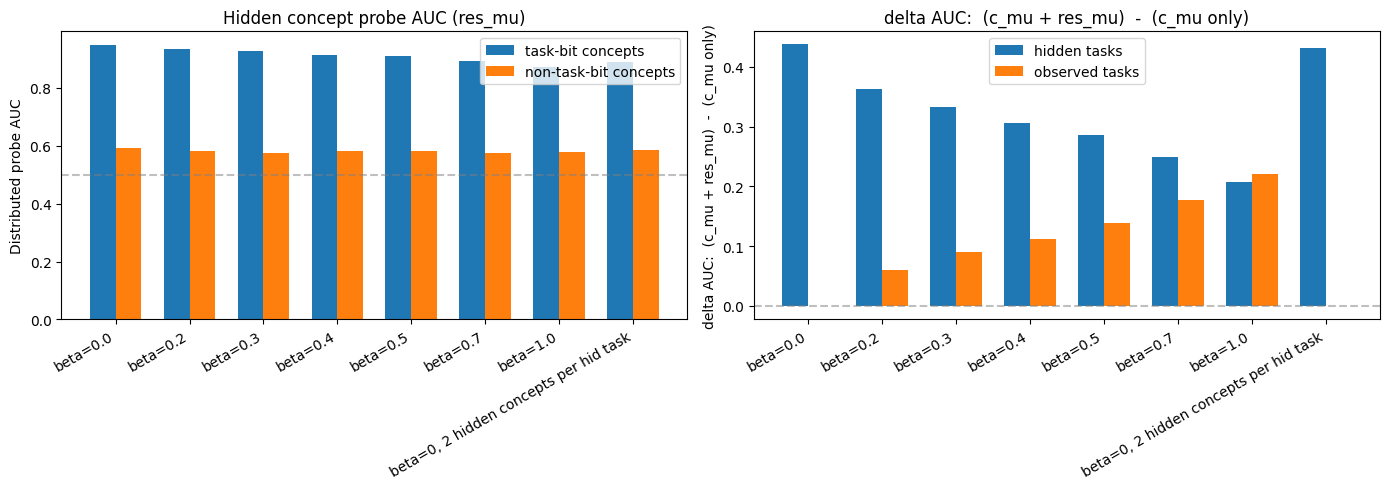

In [790]:
# ============================================================
# Bar charts: hidden concept probe AUC, and conditional value of res_mu
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = list(results_by_label.keys())
x = np.arange(len(labels))
width = 0.35

ax = axes[0]
ax.bar(x - width / 2, probe_summary_df.loc[labels, "hidden_probe_auc_task_bits"], width, label="task-bit concepts")
ax.bar(x + width / 2, probe_summary_df.loc[labels, "hidden_probe_auc_non_task"], width, label="non-task-bit concepts")
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("Distributed probe AUC")
ax.set_title("Hidden concept probe AUC (res_mu)")
ax.legend()

ax = axes[1]
ax.bar(x - width / 2, cmu_summary_df.loc[labels, "cmu_delta_auc_hidden_tasks"], width, label="hidden tasks")
ax.bar(x + width / 2, cmu_summary_df.loc[labels, "cmu_delta_auc_observed_tasks"], width, label="observed tasks")
ax.axhline(0.0, color="grey", linestyle="--", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("delta AUC:  (c_mu + res_mu)  -  (c_mu only)")
ax.set_title("delta AUC:  (c_mu + res_mu)  -  (c_mu only)")
ax.legend()

plt.tight_layout()
plt.show()

In [791]:
# ============================================================
# Per-hidden-concept probe AUC, one column per experiment
# ============================================================

pivot_hidden = pd.concat(
    [res["probe_hidden"].assign(experiment=label) for label, res in results_by_label.items()]
)[["experiment", "hidden_concept_idx", "is_task_bit", "distributed_auc"]]

pivot_hidden = (
    pivot_hidden
    .pivot(index="hidden_concept_idx", columns="experiment", values="distributed_auc")
    .reindex(columns=list(results_by_label.keys()))
)

any_exp = next(iter(results_by_label.values()))
task_bit_rows = set(any_exp["exp"]["hid_task_idx_flat"].tolist())
pivot_hidden = pivot_hidden.loc[
    sorted(pivot_hidden.index, key=lambda i: (i not in task_bit_rows, i))
]

def _highlight_task_bits(row):
    return ["font-weight: bold" if row.name in task_bit_rows else "" for _ in row]

display(
    pivot_hidden.style
    .format("{:.3f}")
    .background_gradient(cmap="viridis", vmin=0.5, vmax=1.0)
    .apply(_highlight_task_bits, axis=1)
)
print("Bold rows = task-bit hidden concepts (hid_task_idx). Assumes all experiments share the same hid_dim/task indices.")

experiment,beta=0.0,beta=0.2,beta=0.3,beta=0.4,beta=0.5,beta=0.7,beta=1.0,"beta=0, 2 hidden concepts per hid task"
hidden_concept_idx,,,,,,,,
2,0.947,0.933,0.919,0.908,0.903,0.882,0.858,0.881
5,0.943,0.932,0.926,0.911,0.910,0.895,0.875,0.892
7,0.951,0.940,0.929,0.917,0.912,0.897,0.877,0.891
14,0.950,0.934,0.926,0.916,0.910,0.895,0.881,0.894
17,0.950,0.940,0.931,0.917,0.910,0.889,0.868,0.886
0,0.590,0.578,0.548,0.558,0.576,0.586,0.616,0.545
1,0.584,0.580,0.584,0.585,0.560,0.587,0.573,0.621
3,0.612,0.591,0.571,0.603,0.584,0.544,0.563,0.566
4,0.572,0.579,0.565,0.582,0.598,0.566,0.594,0.545


Bold rows = task-bit hidden concepts (hid_task_idx). Assumes all experiments share the same hid_dim/task indices.


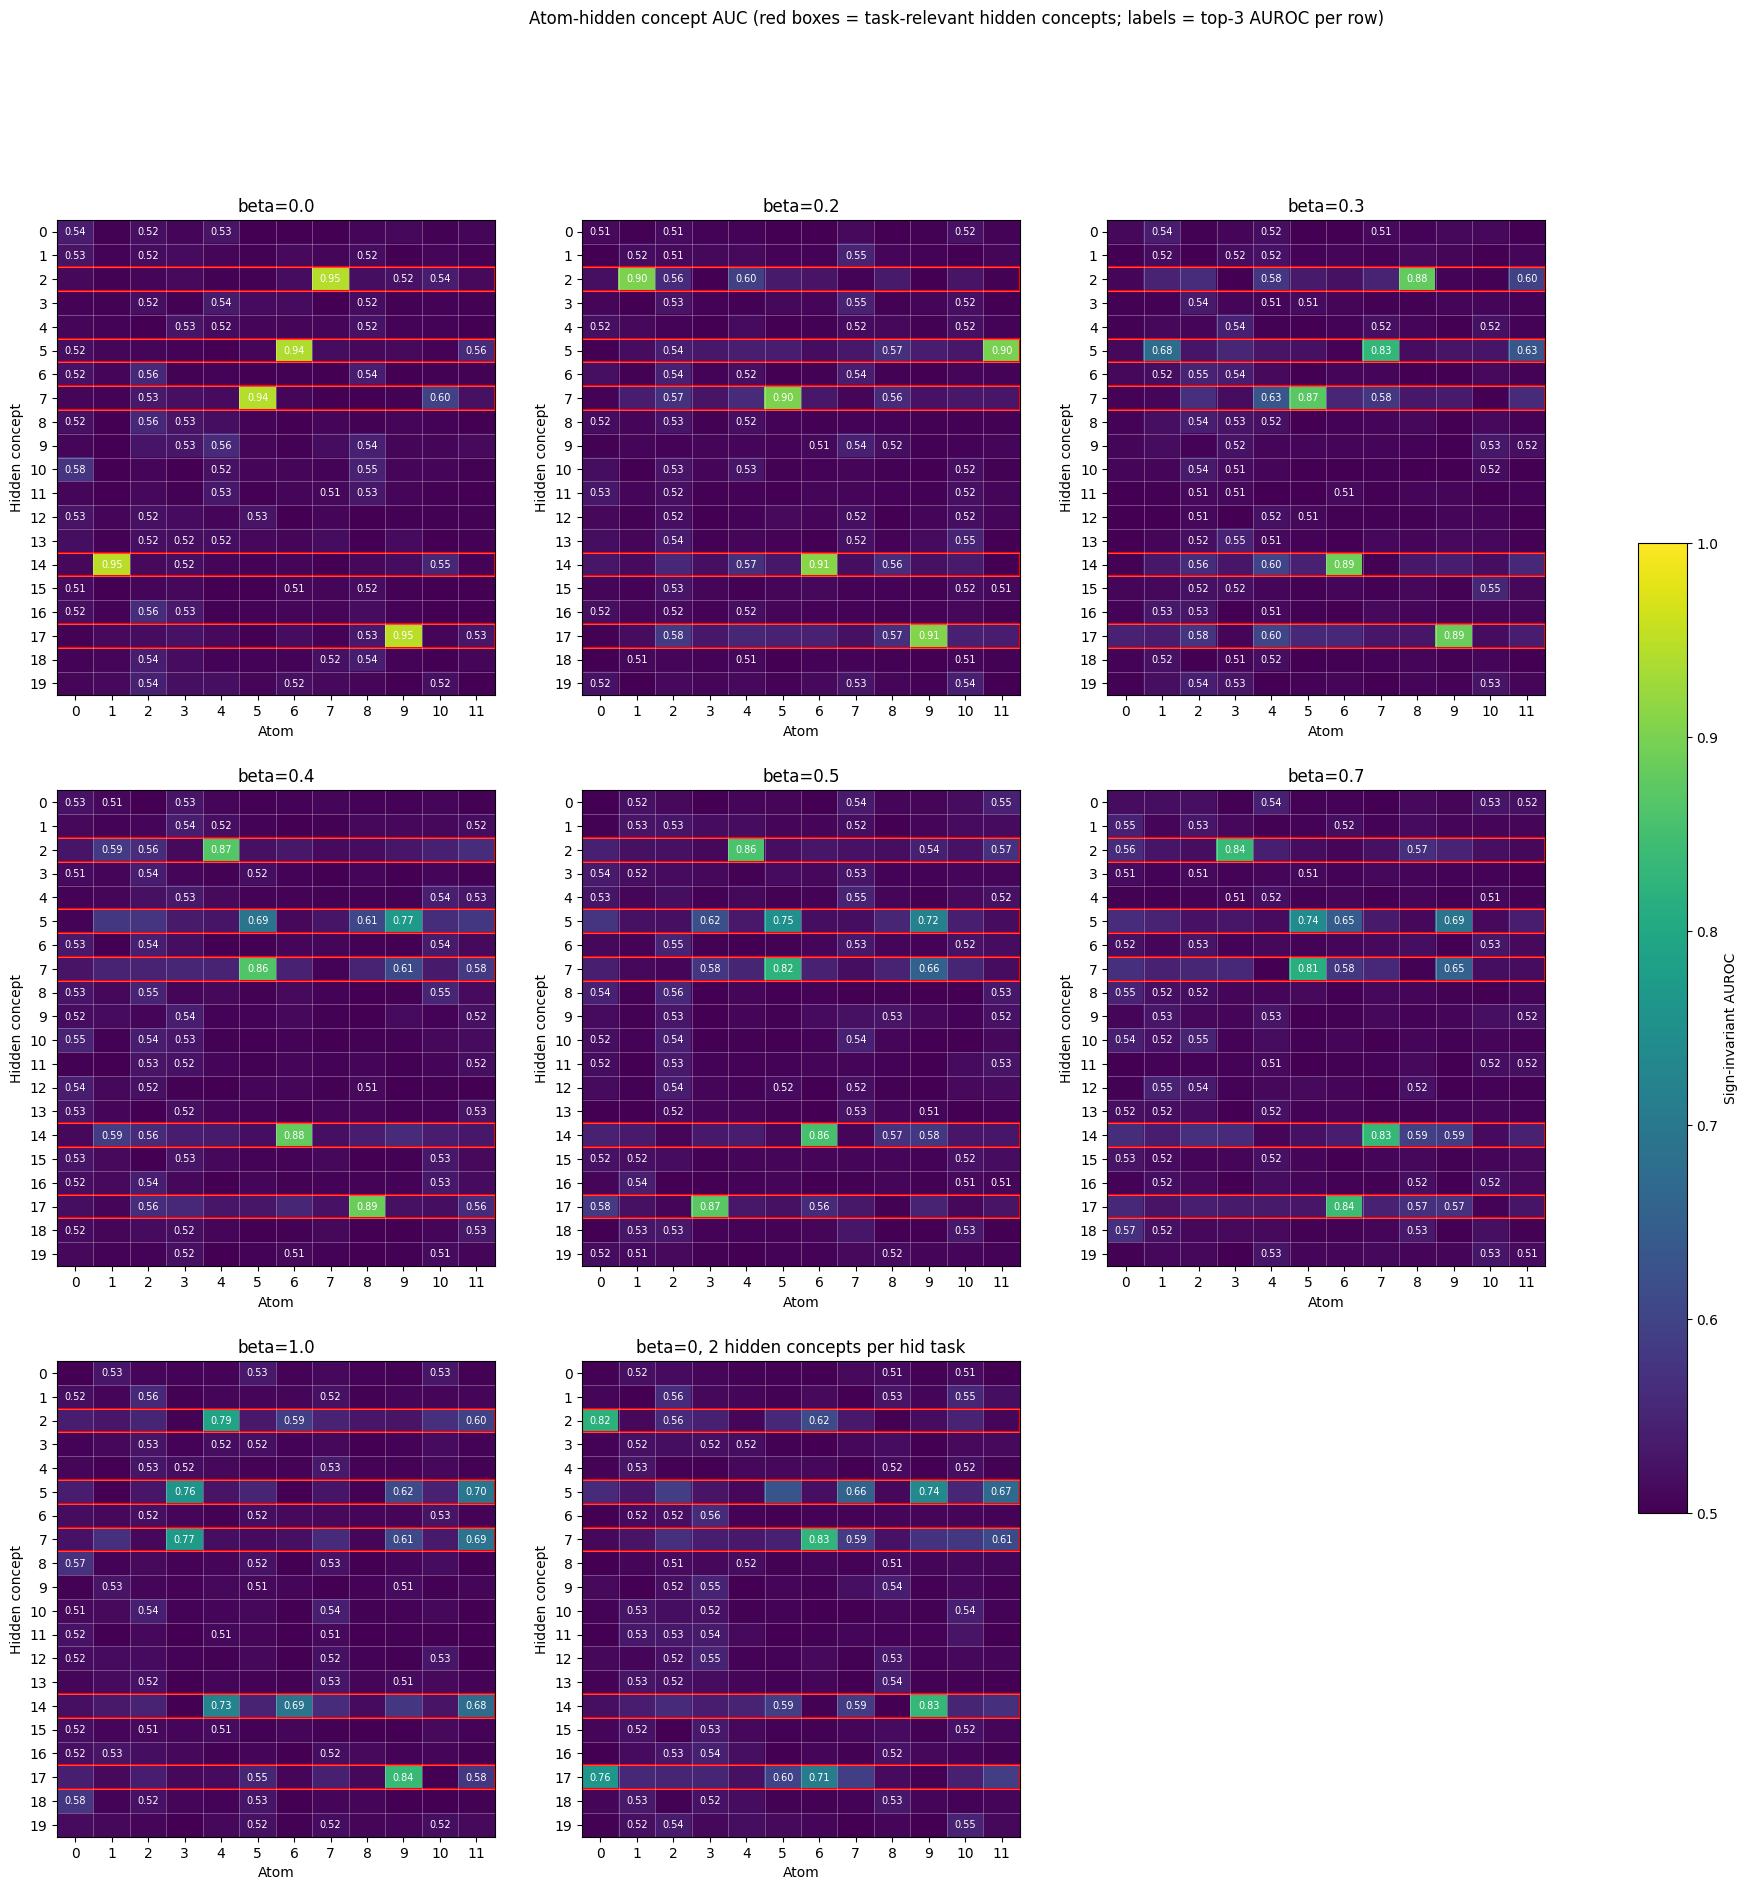

In [792]:
# ============================================================
# Grid of atom-hidden-concept AUC heatmaps, one panel per experiment
# ============================================================

n = len(results_by_label)
ncols = min(3, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows), squeeze=False)

im = None
for ax, (label, res) in zip(axes.flat, results_by_label.items()):
    mat = res["atoms"]["auc_atoms_hidden"]
    im = ax.imshow(mat, aspect="auto", vmin=0.5, vmax=1.0)
    ax.set_title(label)
    ax.set_xlabel("Atom")
    ax.set_ylabel("Hidden concept")
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_yticks(np.arange(mat.shape[0]))
    for r in res["exp"]["hid_task_idx_flat"]:
        ax.add_patch(plt.Rectangle((-0.5, r - 0.5), mat.shape[1], 1, fill=False, edgecolor="red", lw=1.5))
        
    # Gridlines between cells
    ax.set_xticks(np.arange(mat.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(mat.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate the top-3 highest-AUROC atoms per hidden-concept row.
    for i in range(mat.shape[0]):
        row = mat[i]
        valid = np.where(~np.isnan(row))[0]
        if len(valid) == 0:
            continue
        top_j = valid[np.argsort(row[valid])[::-1][:3]]
        for j in top_j:
            ax.text(j, i, f"{row[j]:.2f}", ha="center", va="center", fontsize=7, color="white")

for ax in axes.flat[n:]:
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="Sign-invariant AUROC")
fig.suptitle("Atom-hidden concept AUC (red boxes = task-relevant hidden concepts; labels = top-3 AUROC per row)")
plt.show()

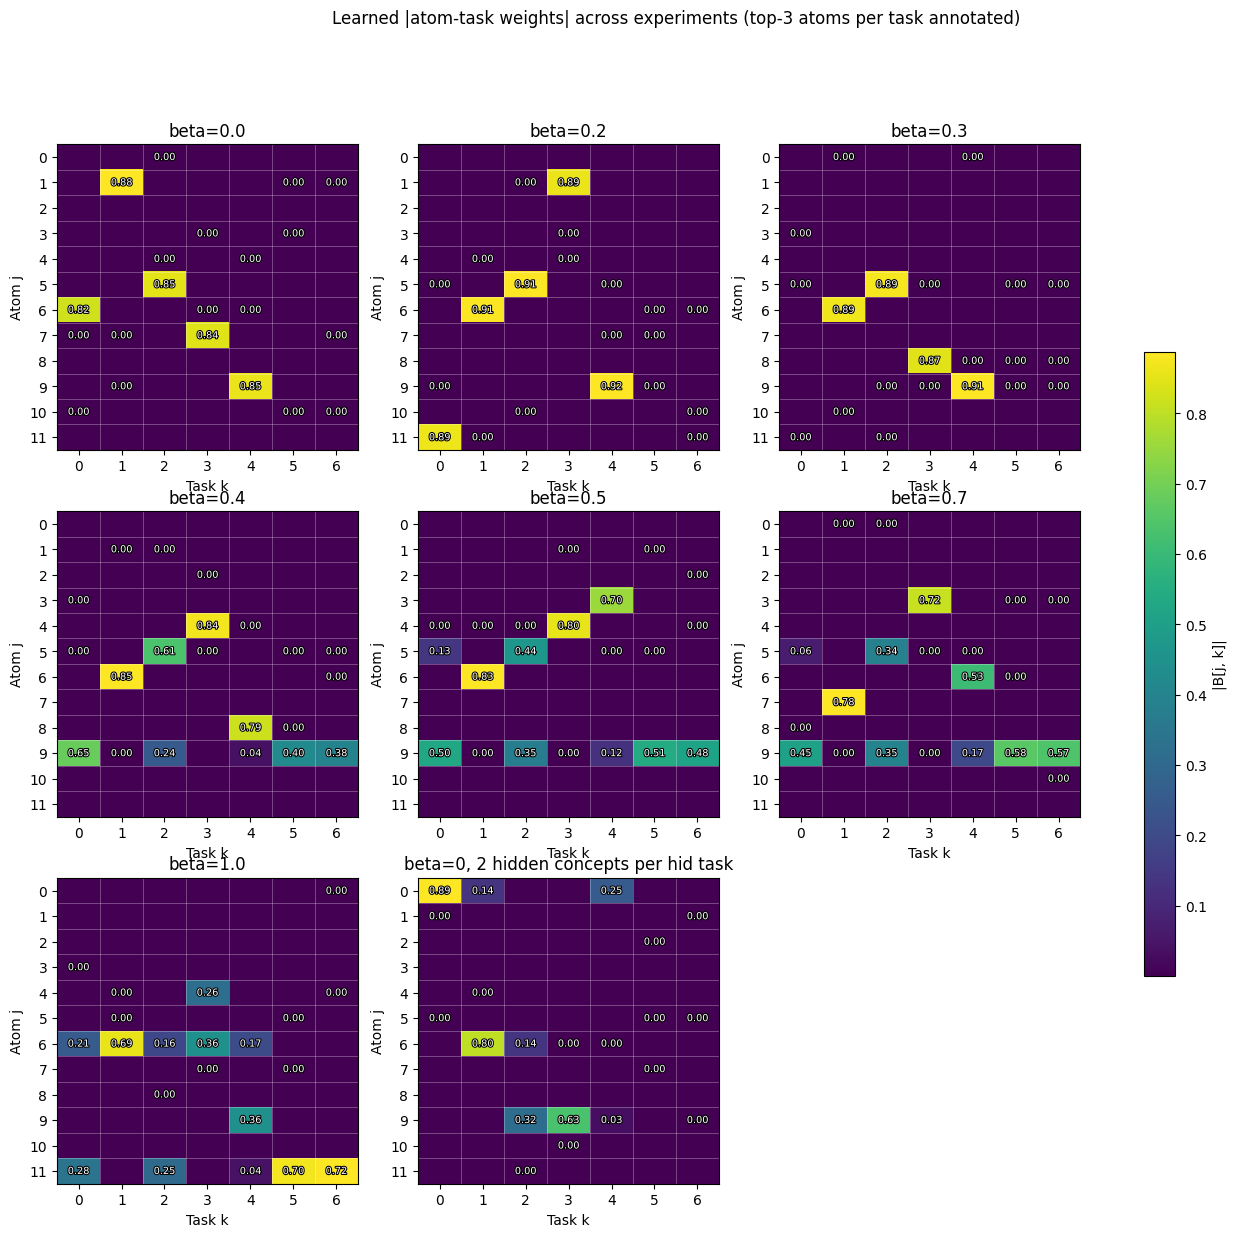

In [793]:
# ============================================================
# Grid of learned |B| (atom-task weight) heatmaps, one panel per experiment
# ============================================================

import matplotlib.patheffects as pe

n = len(results_by_label)
ncols = min(3, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows), squeeze=False)

im = None
for ax, (label, res) in zip(axes.flat, results_by_label.items()):
    B = res["atoms"]["B"]
    B_abs = np.abs(B)
    im = ax.imshow(B_abs, aspect="auto")
    ax.set_title(label)
    ax.set_xlabel("Task k")
    ax.set_ylabel("Atom j")
    ax.set_xticks(np.arange(B.shape[1]))
    ax.set_yticks(np.arange(B.shape[0]))

    # Gridlines between cells
    ax.set_xticks(np.arange(B.shape[1] + 1) - 0.5, minor=True)
    ax.set_yticks(np.arange(B.shape[0] + 1) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.5, alpha=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate the top-3 atoms (by |B|) in each task column with their value
    n_top = min(3, B_abs.shape[0])
    for k in range(B_abs.shape[1]):
        top_atoms = np.argsort(B_abs[:, k])[::-1][:n_top]
        for j in top_atoms:
            ax.text(
                k, j, f"{B_abs[j, k]:.2f}",
                ha="center", va="center", fontsize=7, color="white",
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

for ax in axes.flat[n:]:
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label="|B[j, k]|")
fig.suptitle("Learned |atom-task weights| across experiments (top-3 atoms per task annotated)")
plt.show()

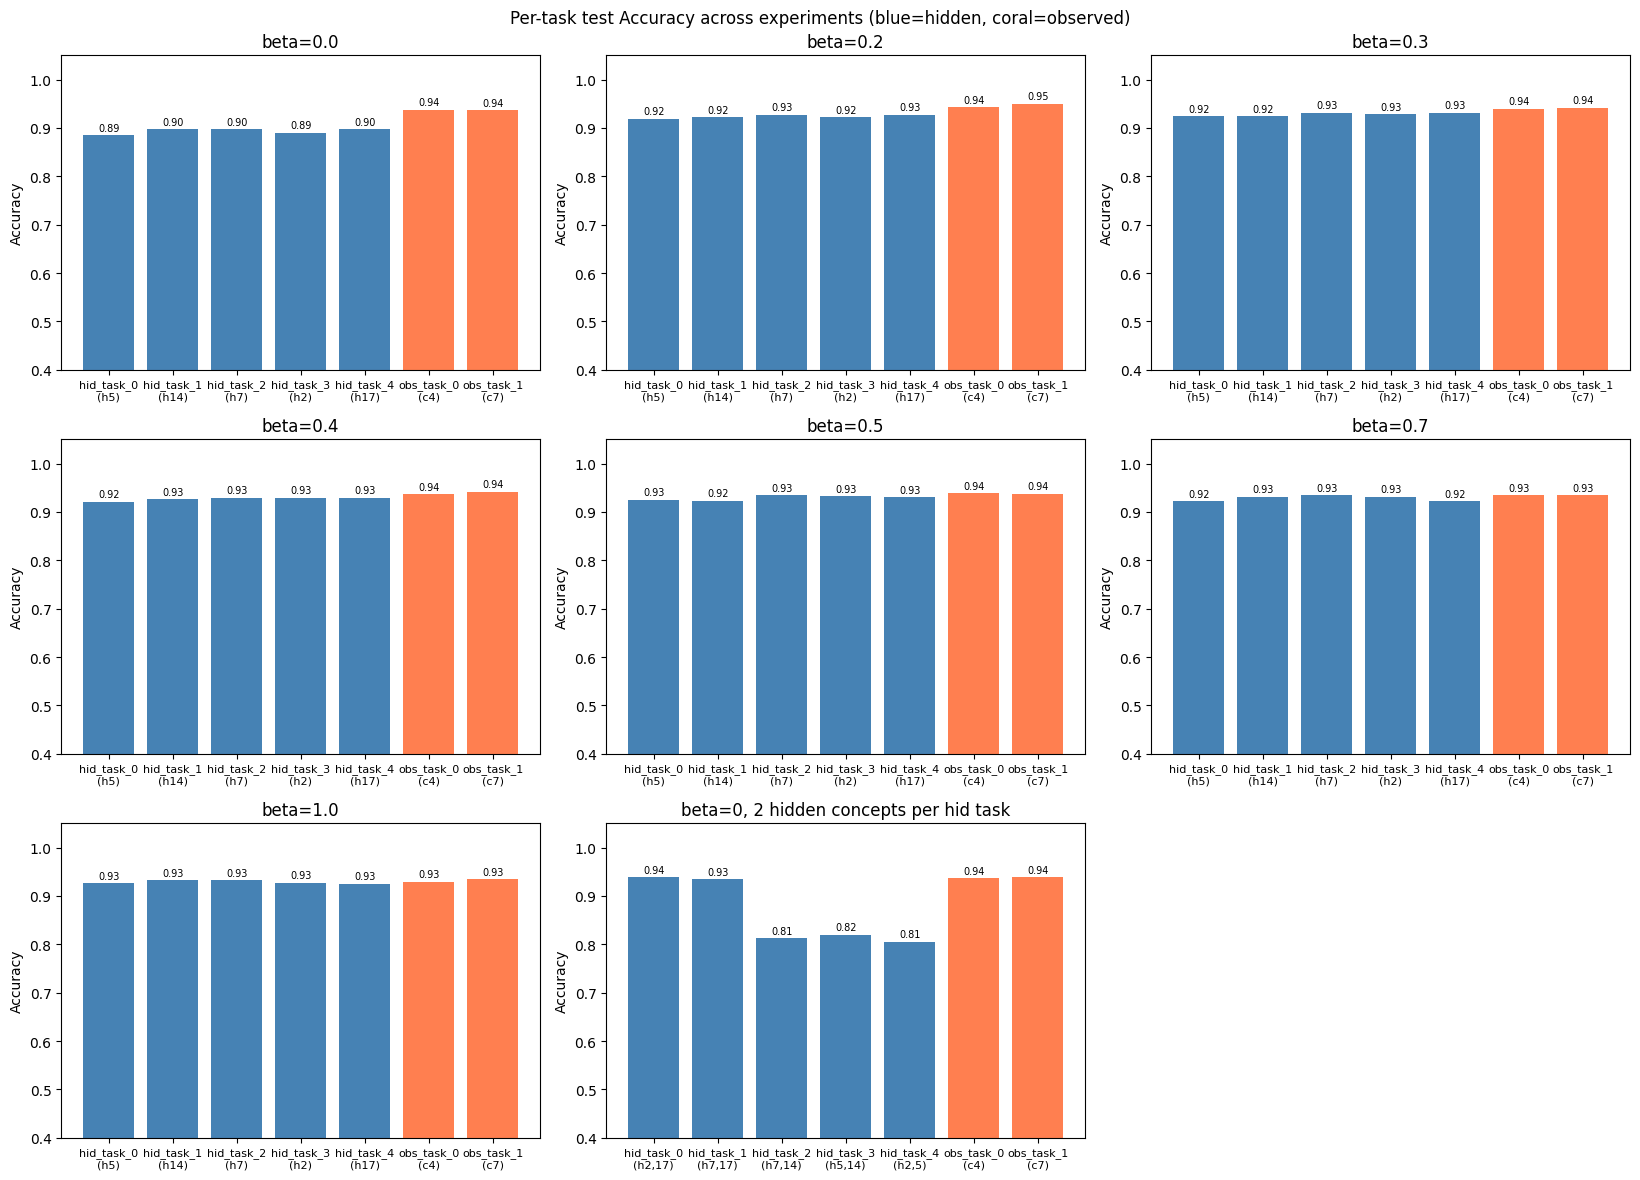

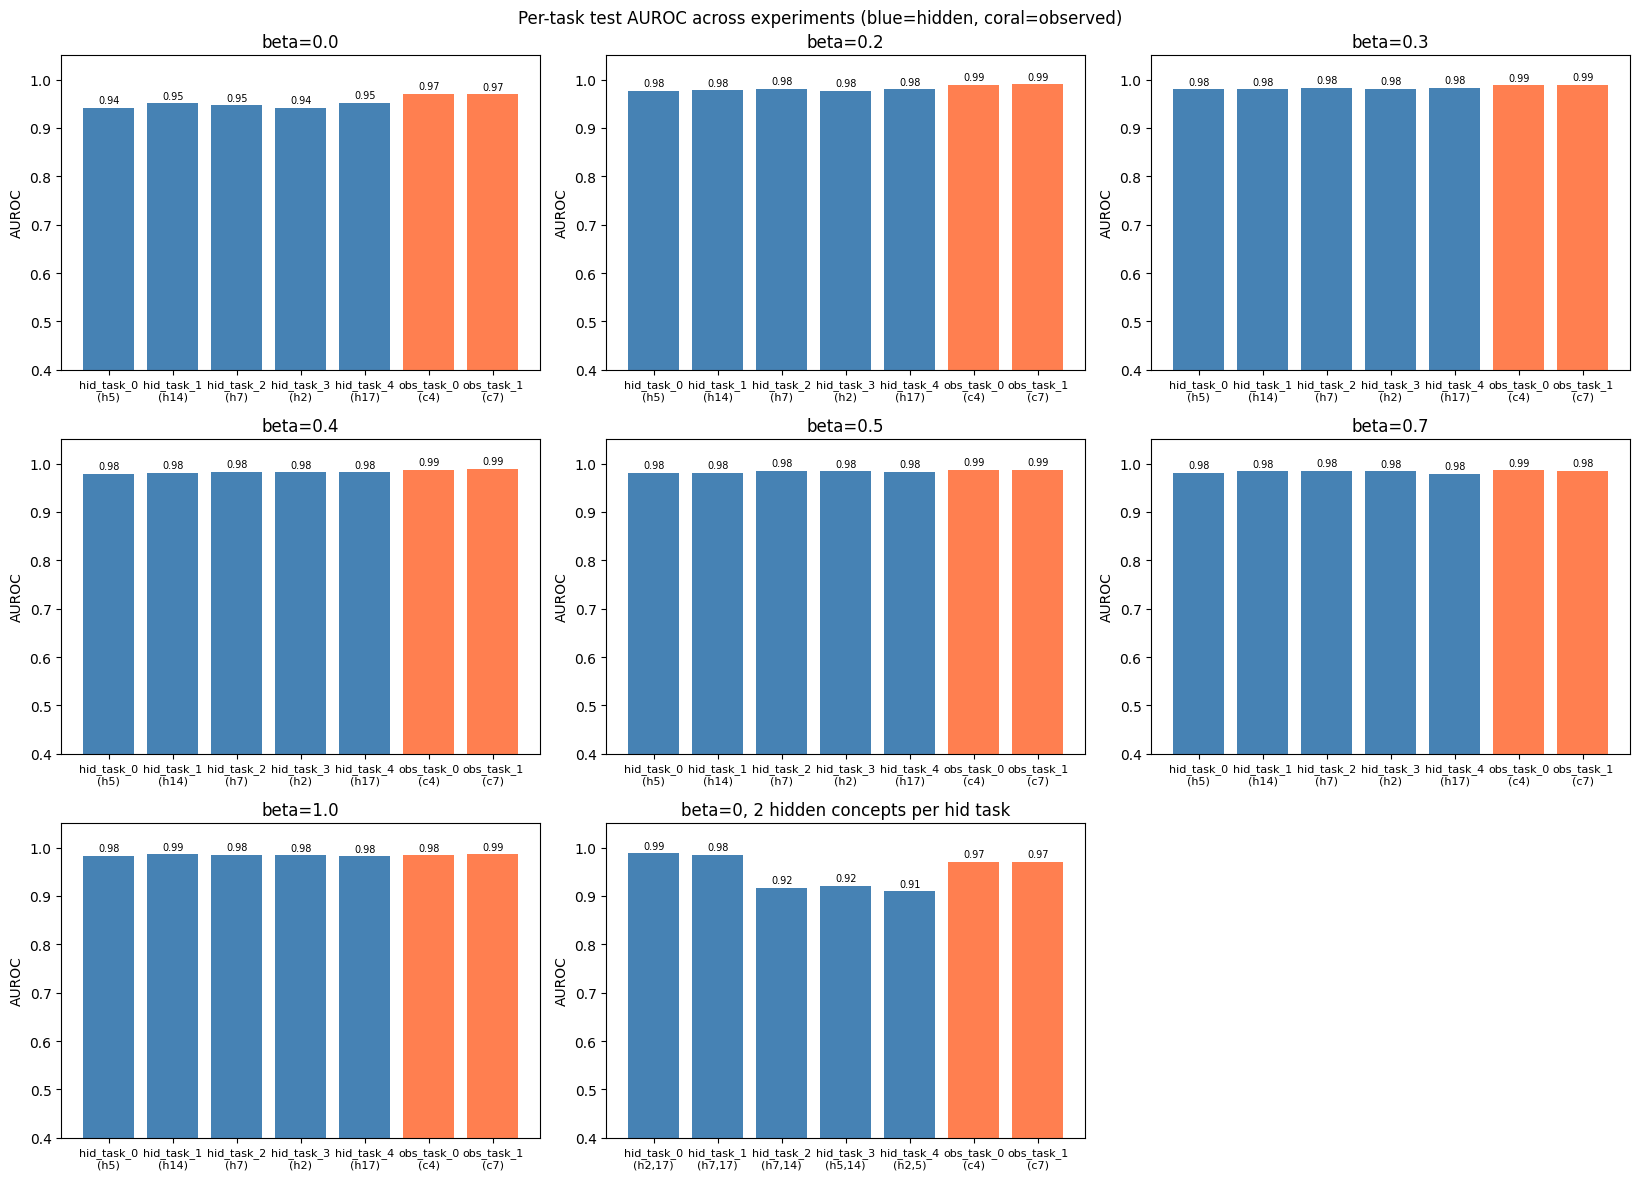

In [794]:
# ============================================================
# Grid of per-task test accuracy / AUROC, one panel per experiment
# ============================================================
# Same metrics/labels as get_model_performance + plot_per_task_metric above
# (Test accuracy/AUROC per task, parsed from each run's log.txt), laid out
# side by side instead of one figure per experiment.

def _task_labels_for(exp):
    hid_task_idx = exp["hid_task_idx"]
    obs_task_idx = exp["obs_task_idx"]

    def _fmt_hid(k):
        # hid_task_idx[k] is a scalar when M=1, an (M,) array when M>1.
        return ",".join(str(int(i)) for i in np.atleast_1d(hid_task_idx[k]))

    return (
        [f"hid_task_{k}\n(h{_fmt_hid(k)})" for k in range(exp["num_hid_tasks"])]
        + [f"obs_task_{j}\n(c{int(obs_task_idx[j])})" for j in range(exp["num_obs_tasks"])]
    )


def plot_per_task_metric_grid(results_by_label, metric_name="y_accuracy_task", ylim=(0.4, 1.05)):
    display_name = {
        "y_accuracy_task": "Accuracy",
        "y_auroc_task": "AUROC",
    }.get(metric_name, metric_name)

    n = len(results_by_label)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)

    for ax, (label, res) in zip(axes.flat, results_by_label.items()):
        exp = res["exp"]
        task_labels = _task_labels_for(exp)
        colors = ["steelblue"] * exp["num_hid_tasks"] + ["coral"] * exp["num_obs_tasks"]
        values = [res["test_metrics"].get(f"{metric_name}_{k}") for k in range(exp["num_tasks"])]
        plot_values = [0.0 if v is None else v for v in values]

        bars = ax.bar(task_labels, plot_values, color=colors)
        ax.set_ylim(*ylim)
        ax.set_ylabel(display_name)
        ax.set_title(label)
        ax.tick_params(axis="x", labelsize=8)

        for bar, v in zip(bars, values):
            y_pos = ylim[0] + 0.005 if v is None else bar.get_height() + 0.005
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                    "nan" if v is None else f"{v:.2f}", ha="center", va="bottom", fontsize=7)

    for ax in axes.flat[n:]:
        ax.axis("off")

    fig.suptitle(f"Per-task test {display_name} across experiments (blue=hidden, coral=observed)")
    plt.tight_layout()
    plt.show()


plot_per_task_metric_grid(results_by_label, metric_name="y_accuracy_task", ylim=(0.4, 1.05))
plot_per_task_metric_grid(results_by_label, metric_name="y_auroc_task", ylim=(0.4, 1.05))